In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from io import StringIO

gauth = GoogleAuth()
gauth.LoadCredentialsFile("mycreds.txt")  # Load saved credentials

if gauth.credentials is None:
    gauth.LocalWebserverAuth()  # Opens browser for login
elif gauth.access_token_expired:
    gauth.Refresh()
else:
    gauth.Authorize()

gauth.SaveCredentialsFile("mycreds.txt")  # Save credentials for next time
drive = GoogleDrive(gauth)


data_id = '1DQE1SjDisZguvwkIUj4W6Py_yX5RXcbE'
data = drive.CreateFile({'id': data_id})
file_content = data.GetContentString()


Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=578901317340-unhhbi45idj2kngsrltvdjhjvqrhv8hb.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code

Authentication successful.


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df = pd.read_csv(StringIO(file_content))
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


### Missing Values Heatmap

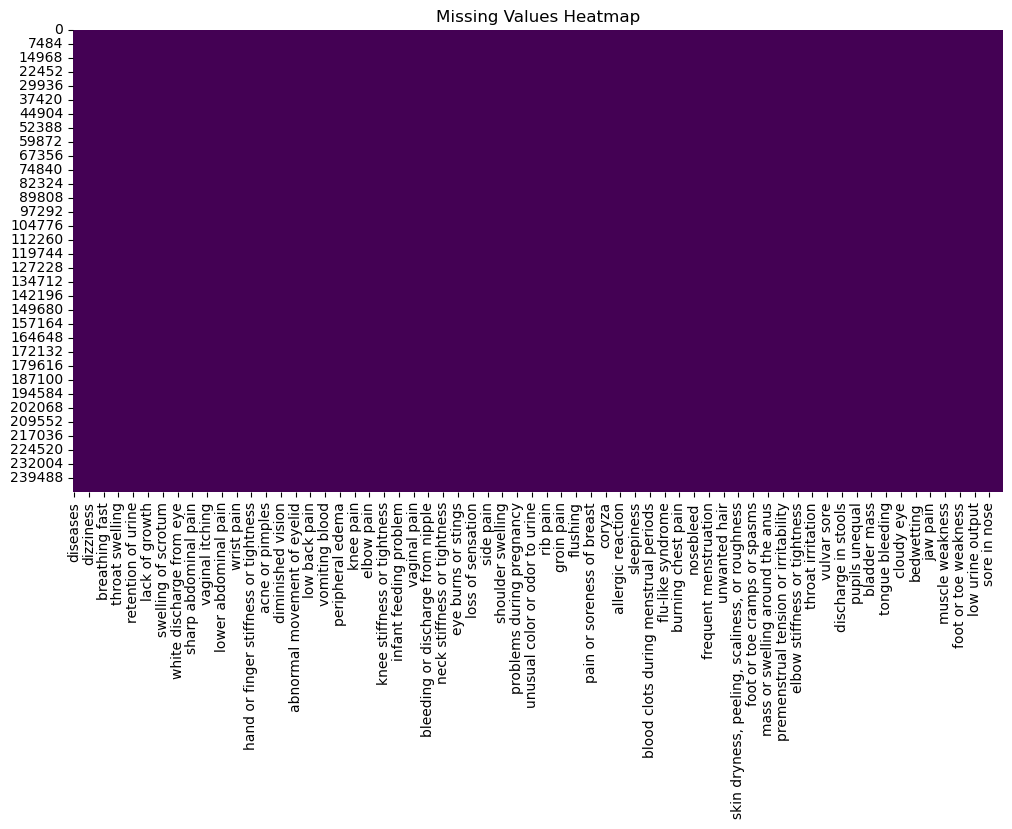

In [3]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

### Distribution of Features (Histograms)

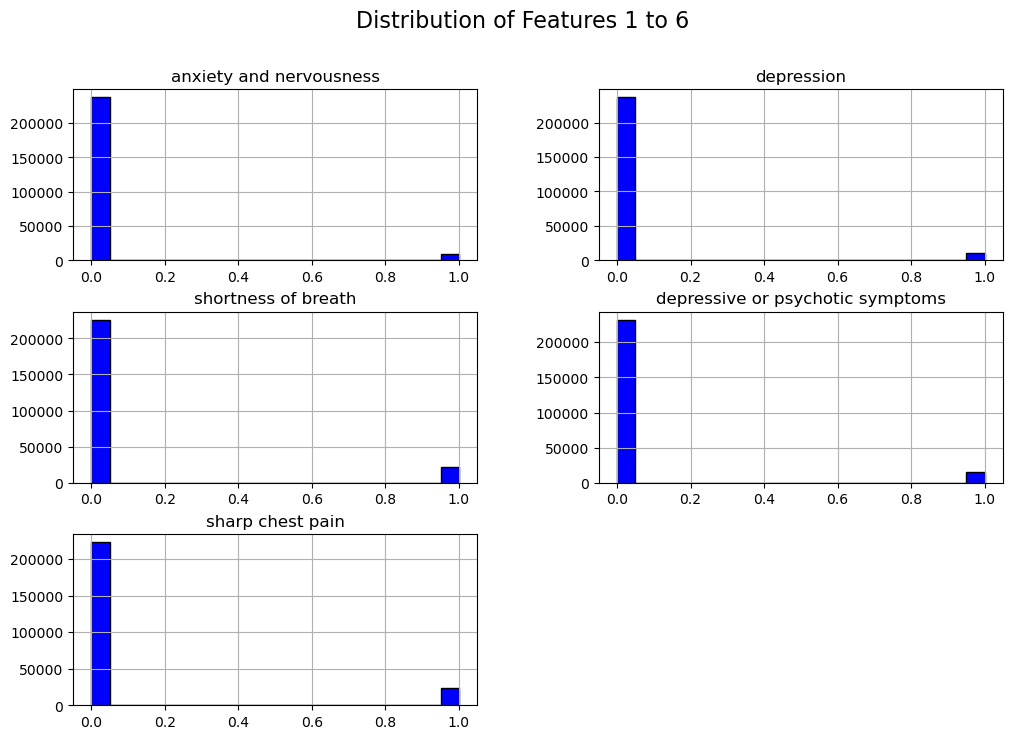

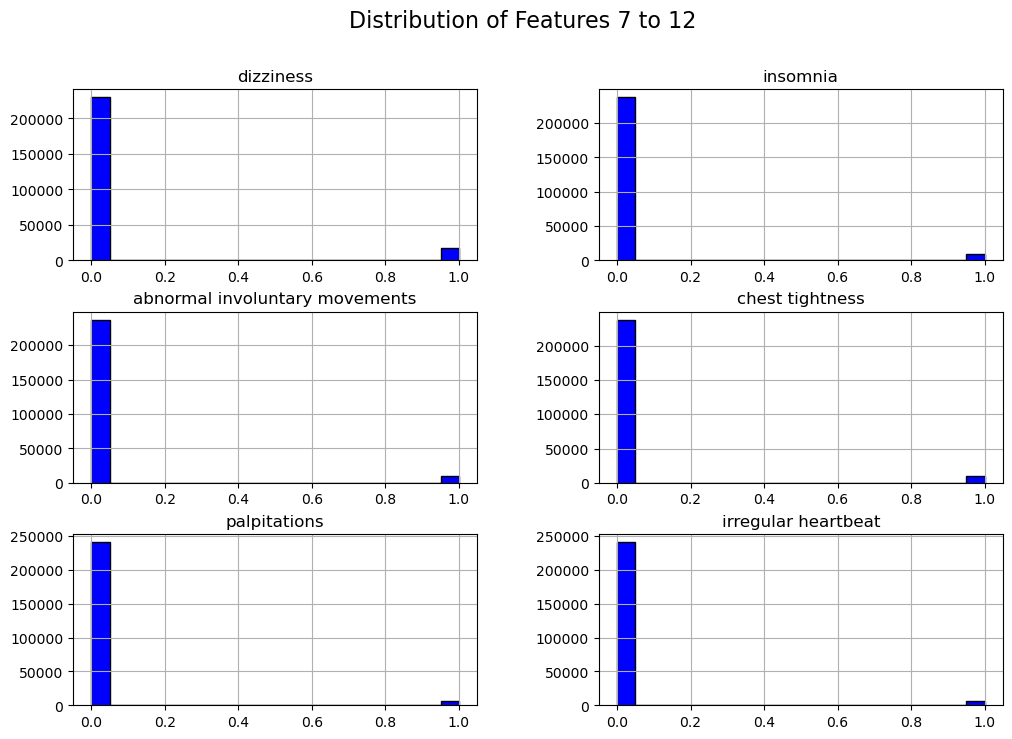

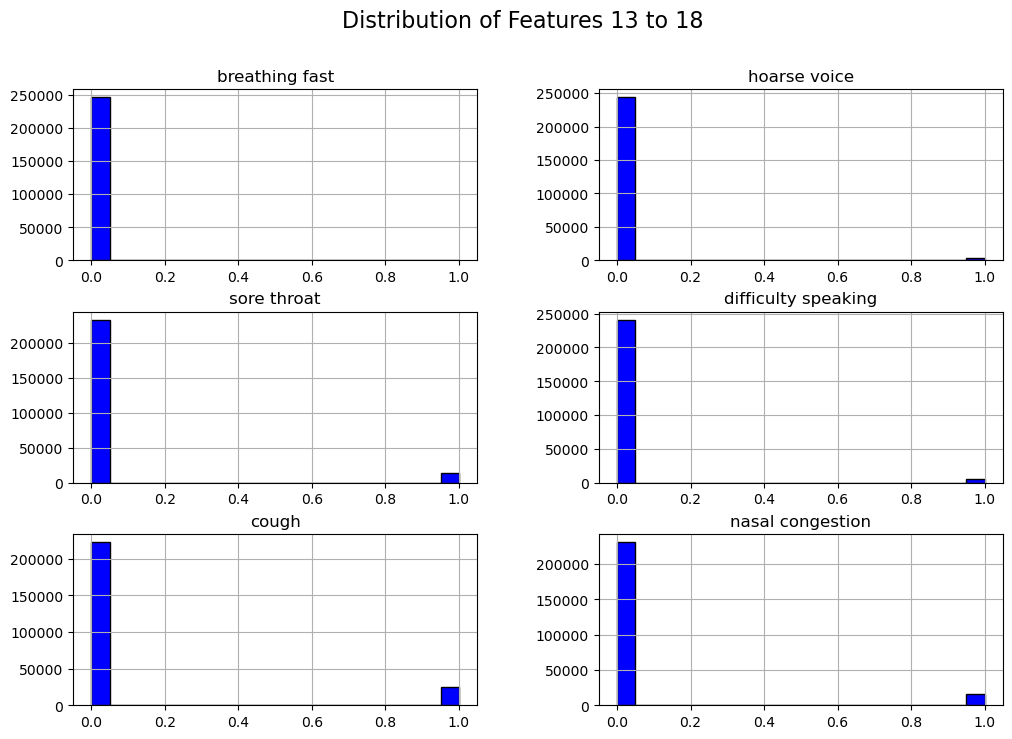

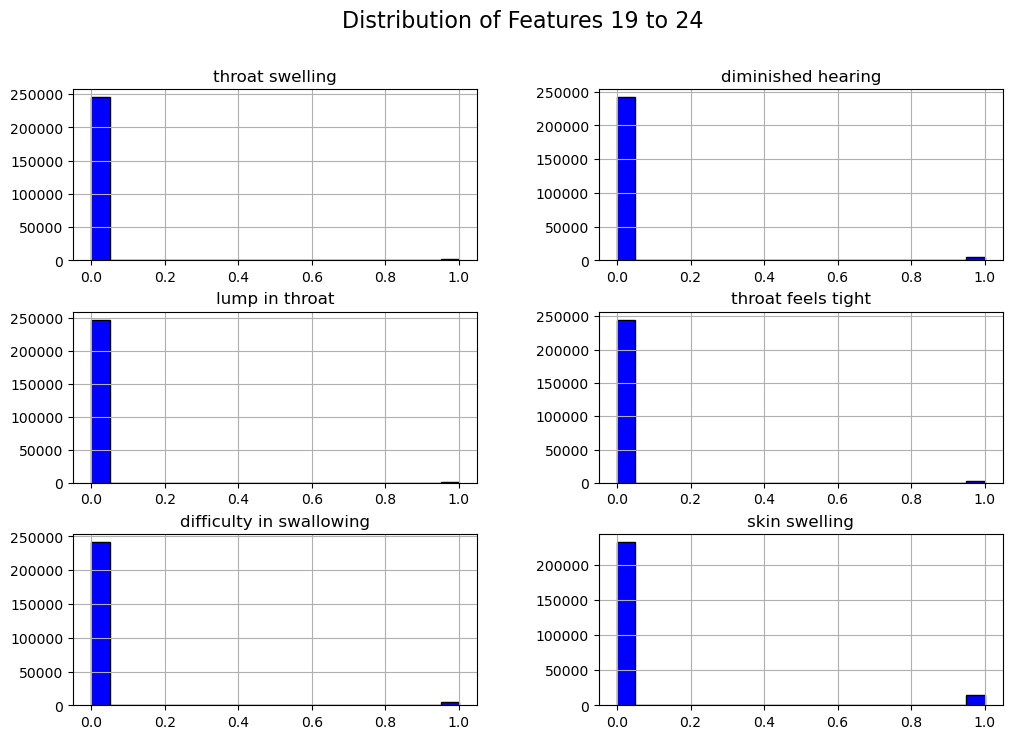

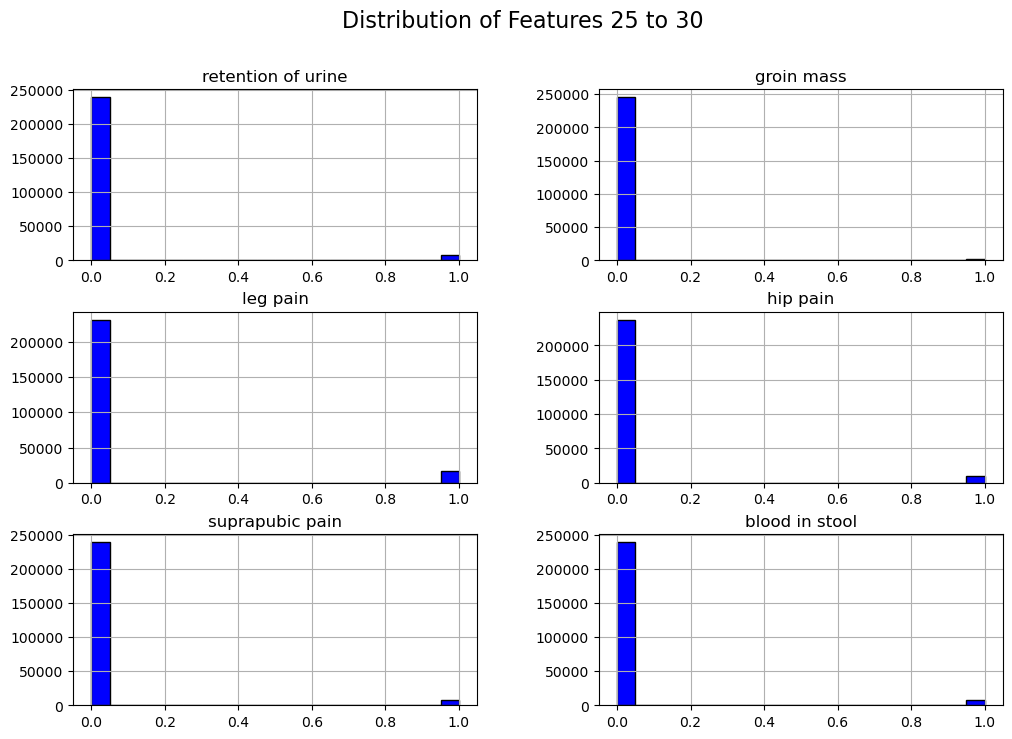

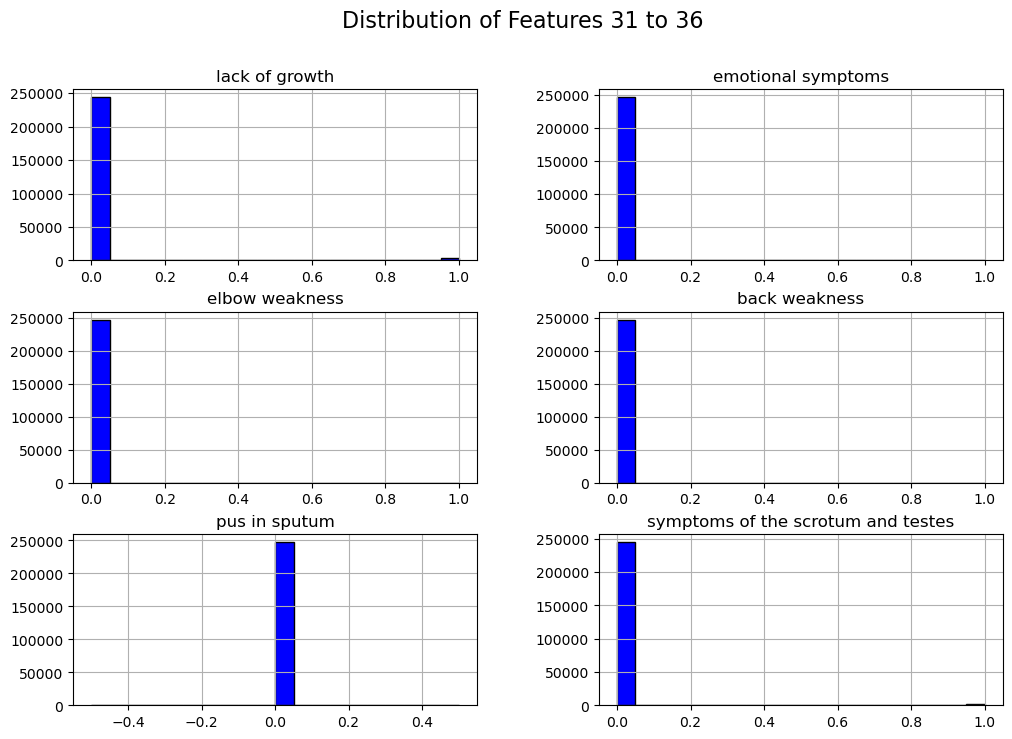

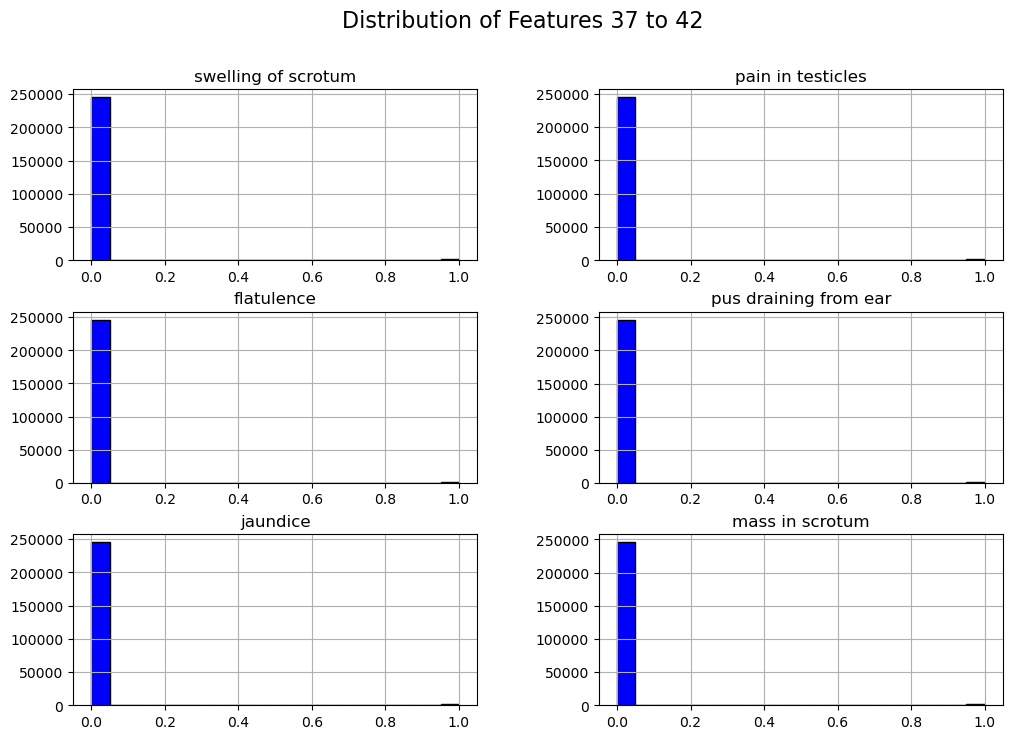

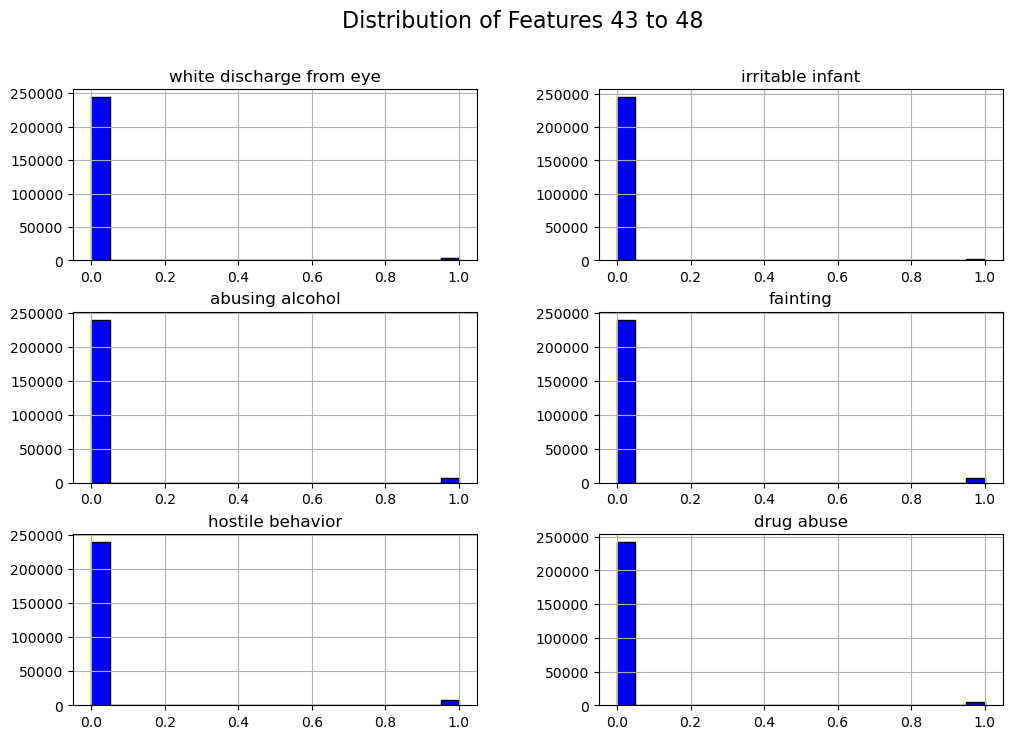

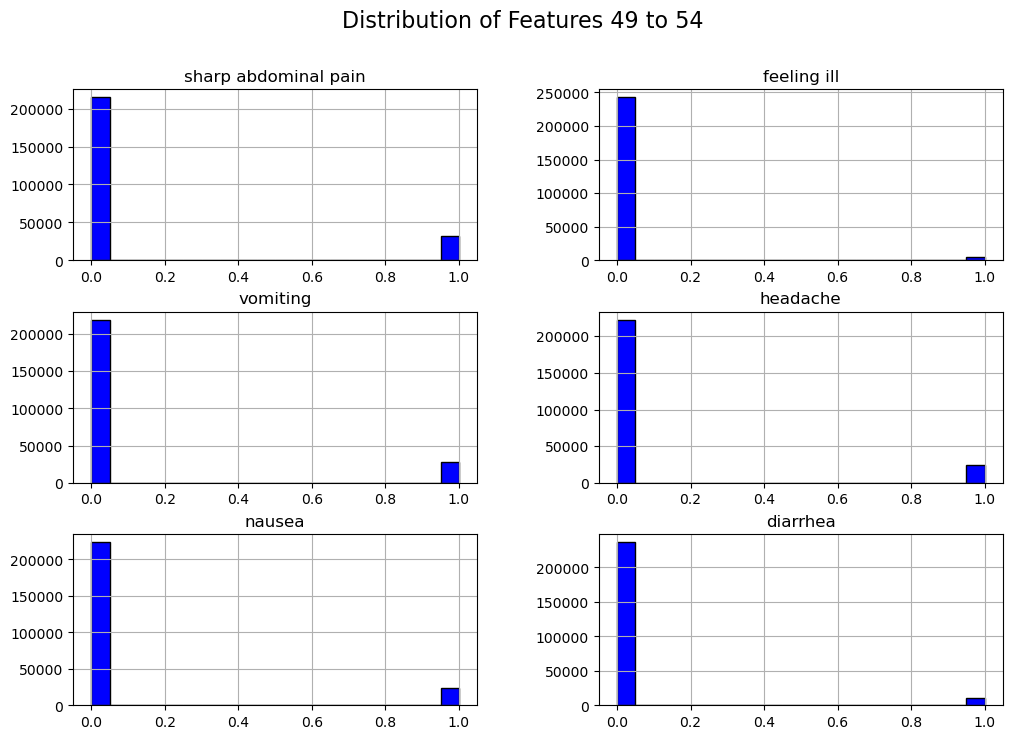

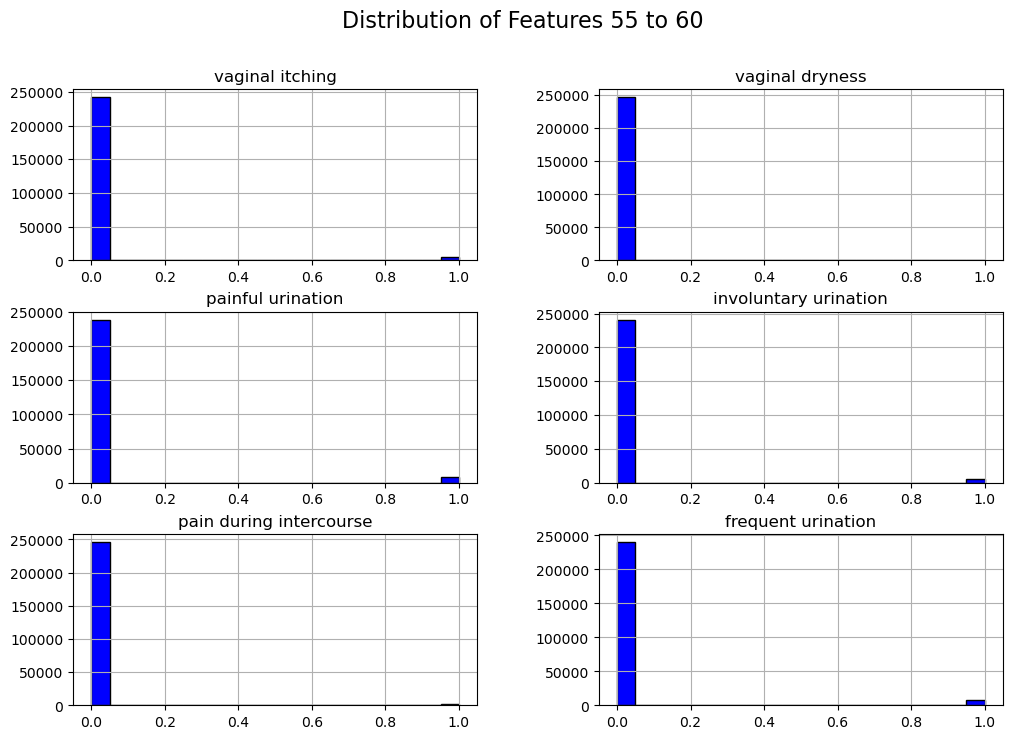

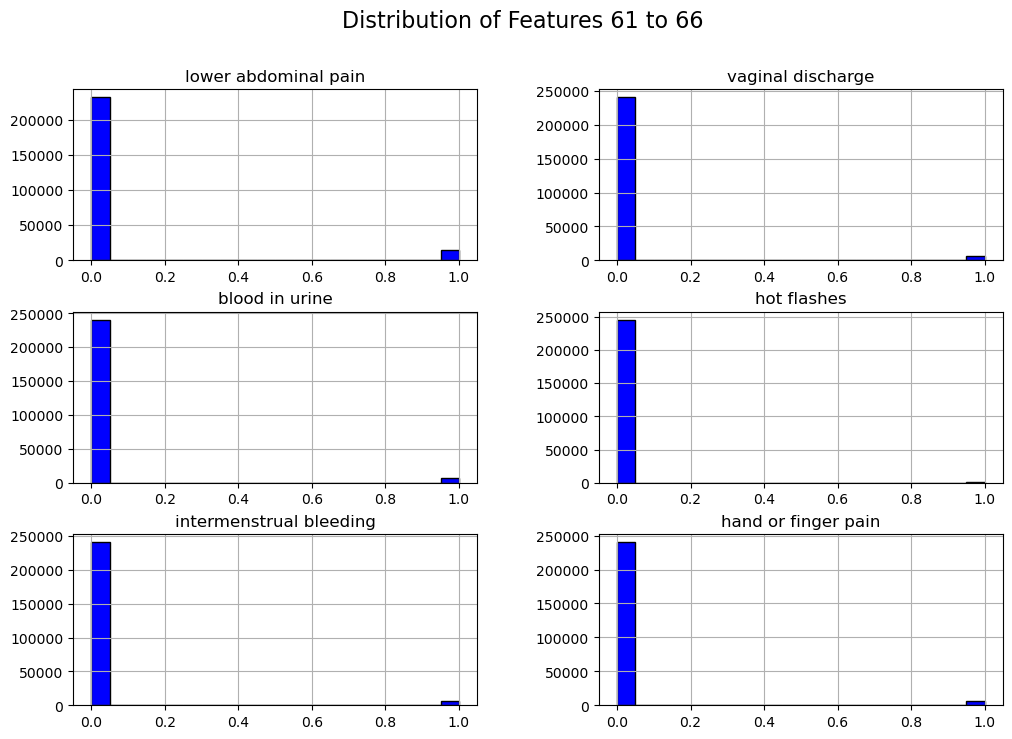

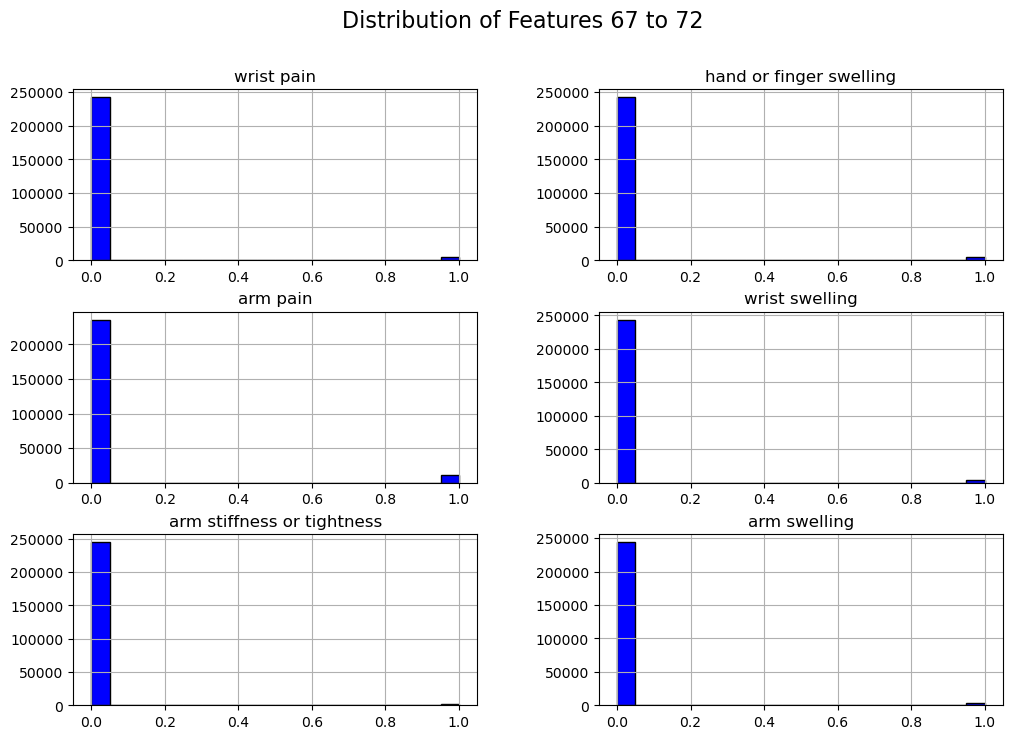

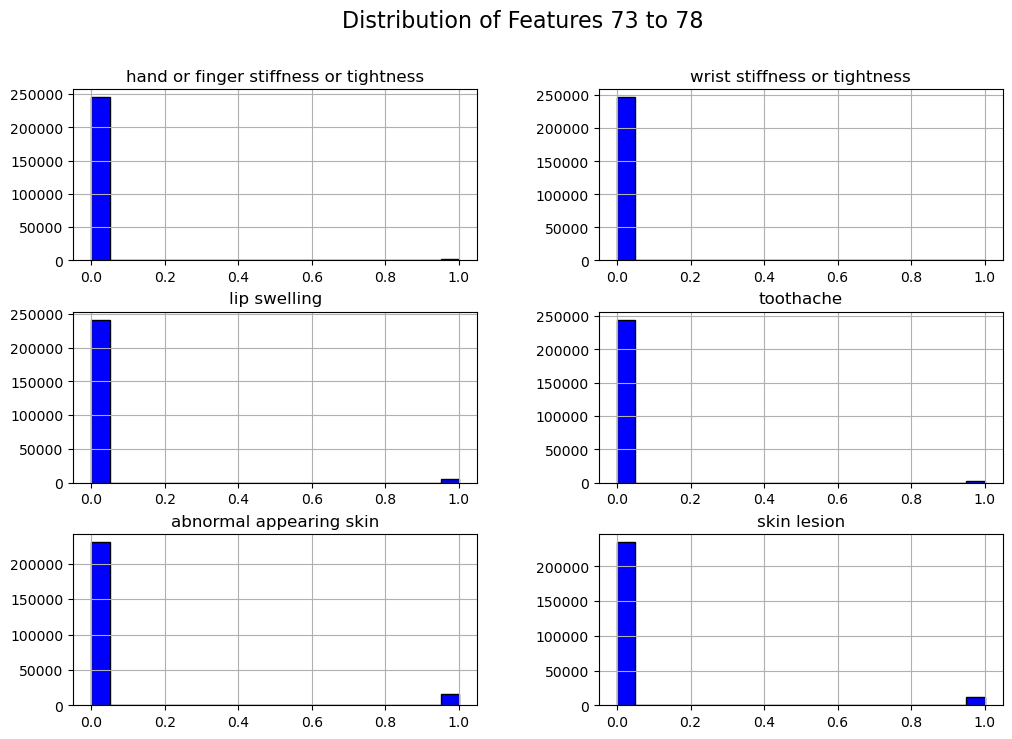

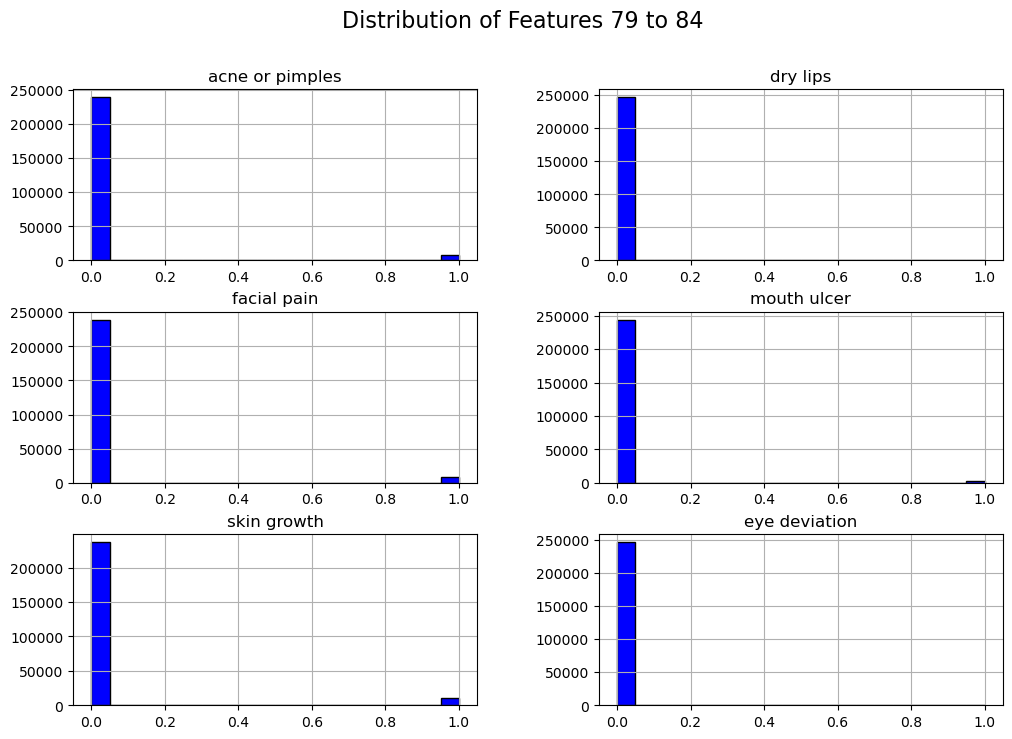

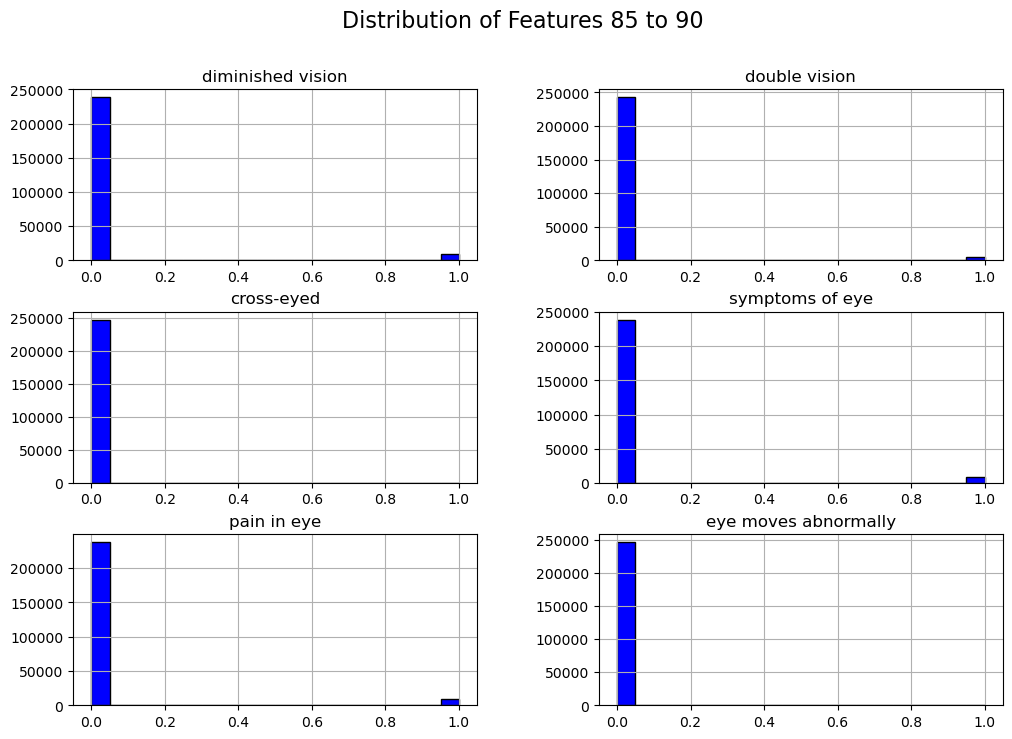

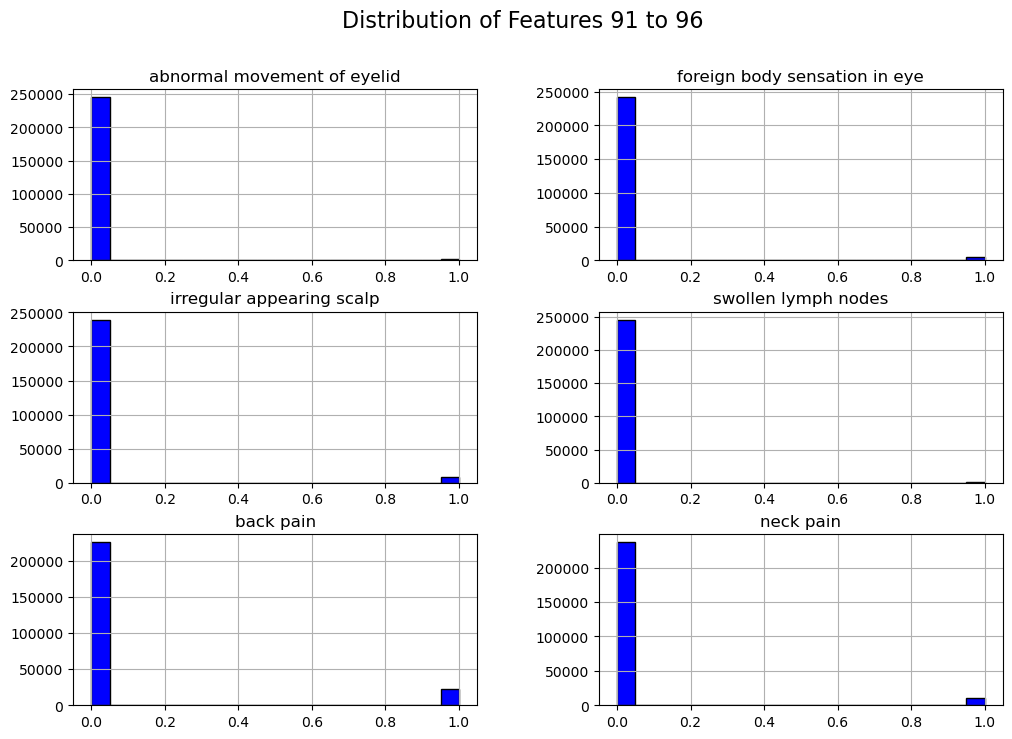

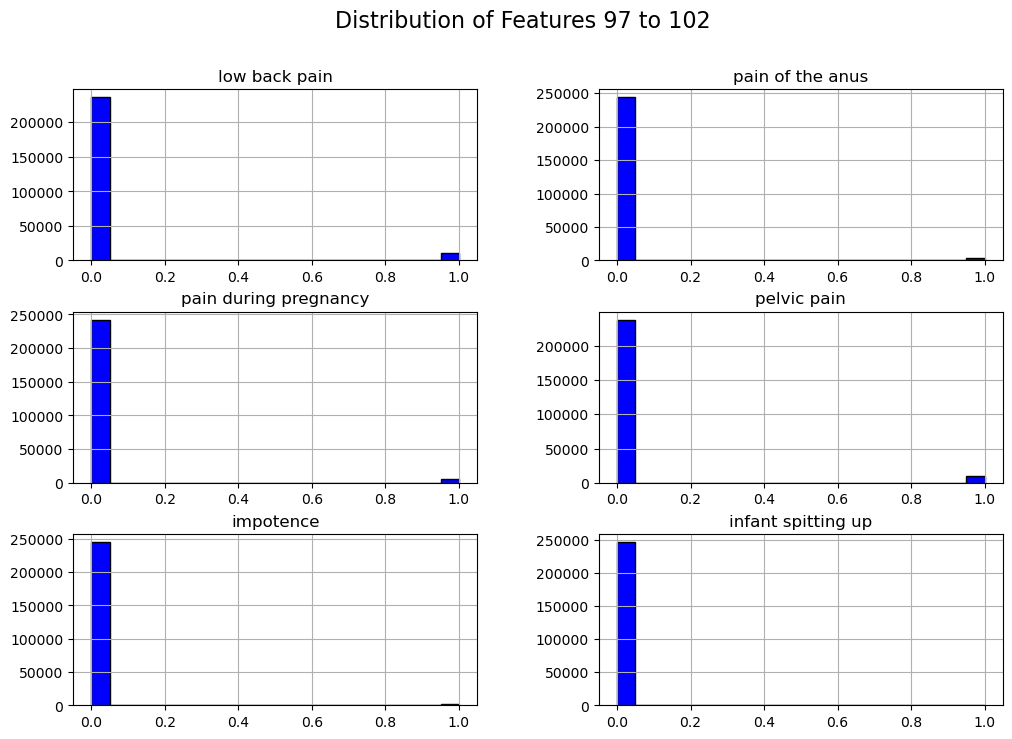

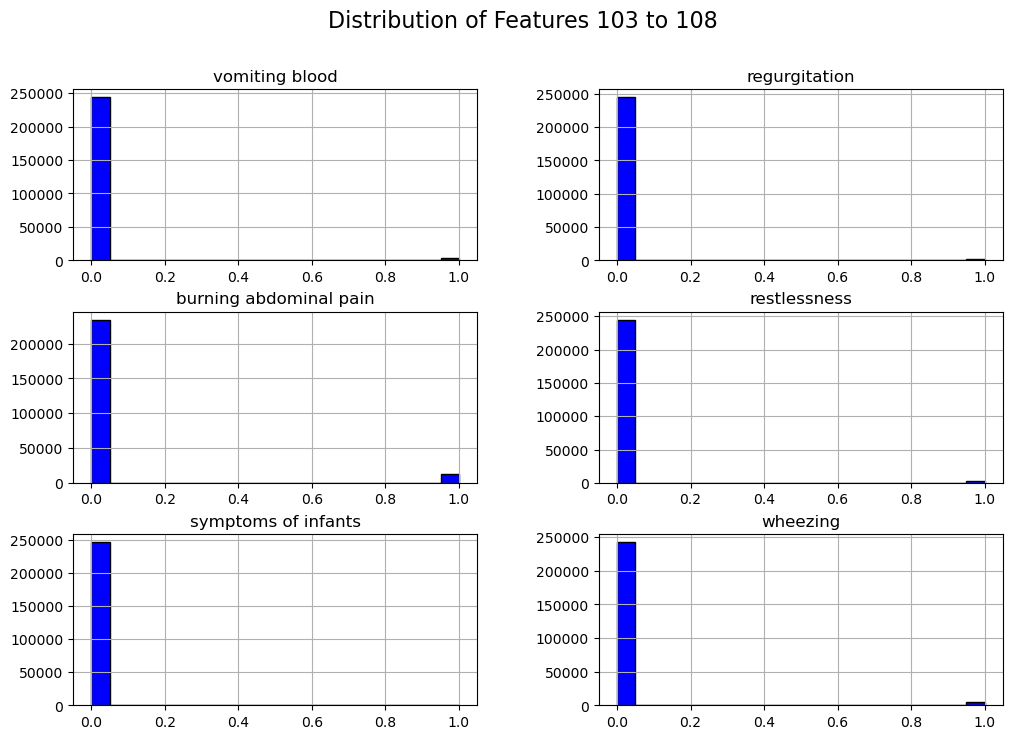

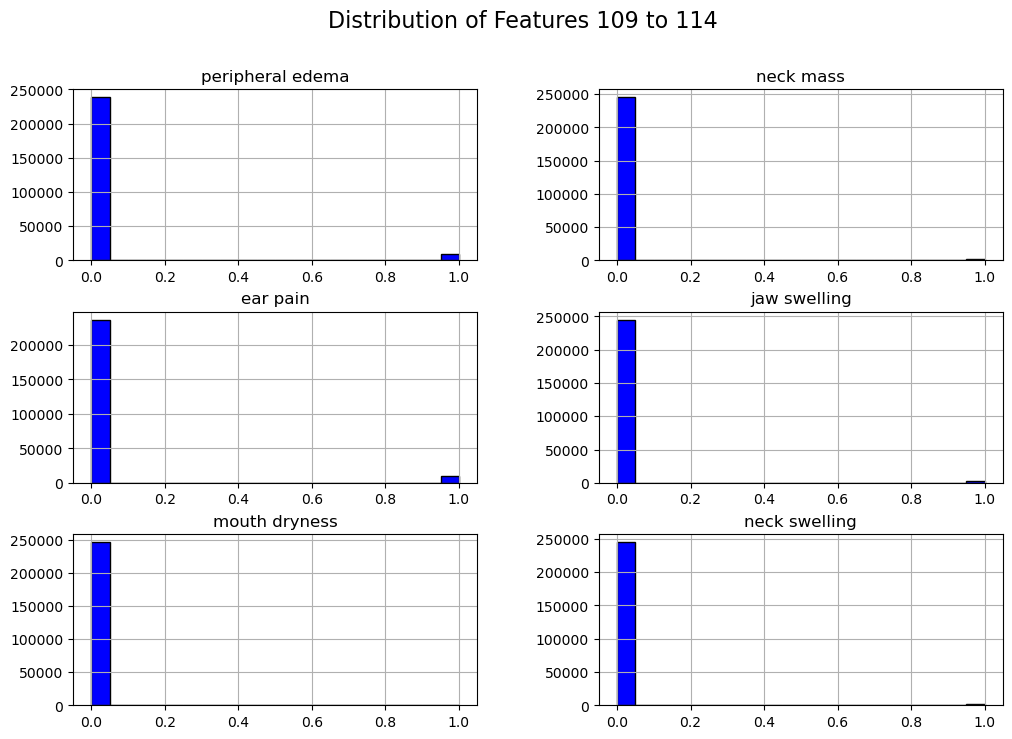

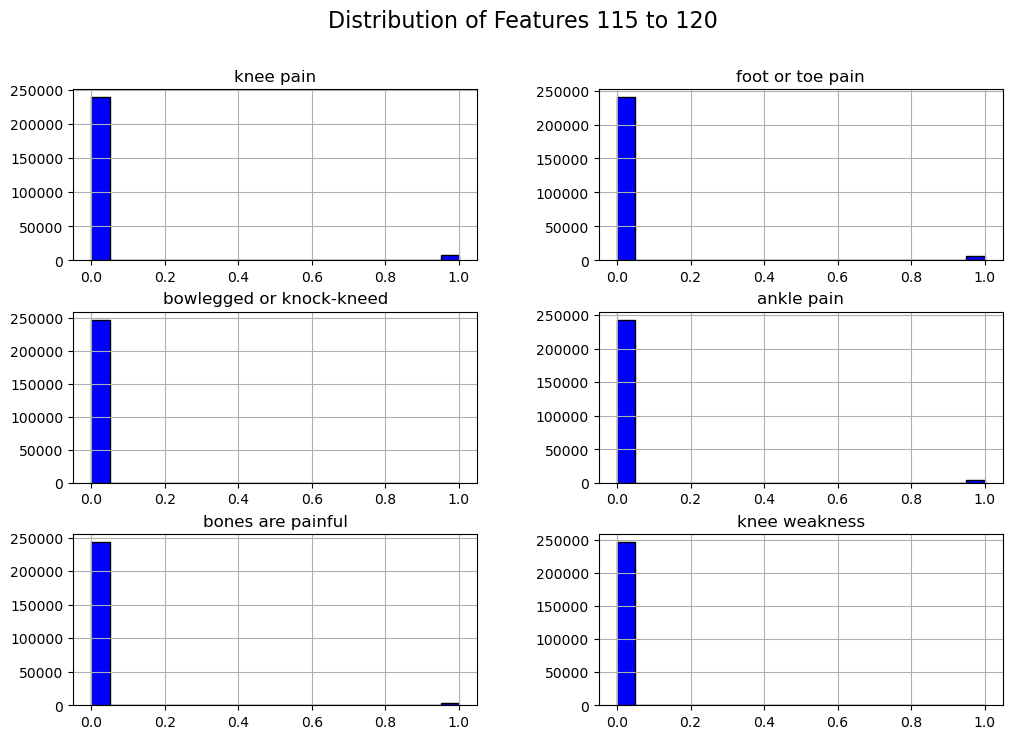

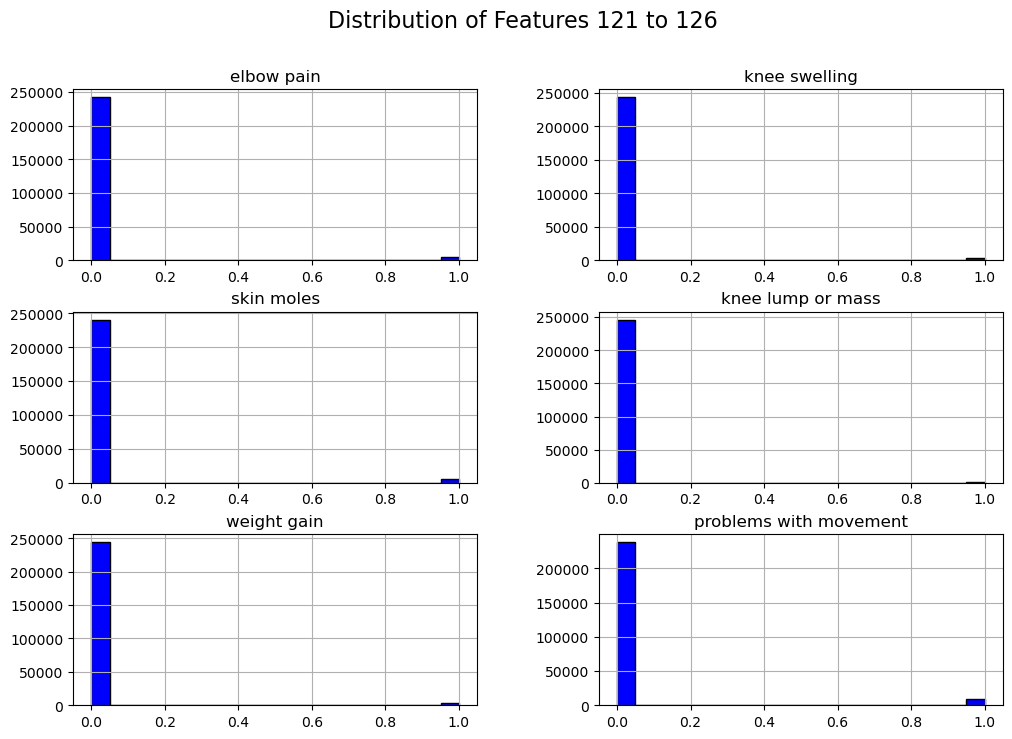

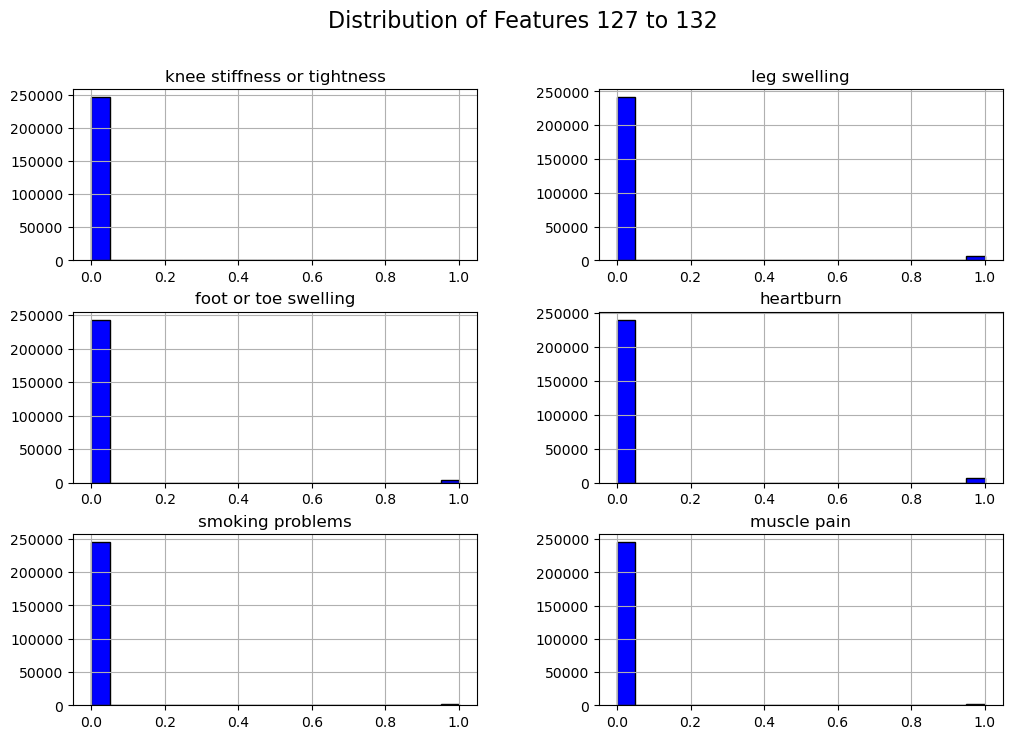

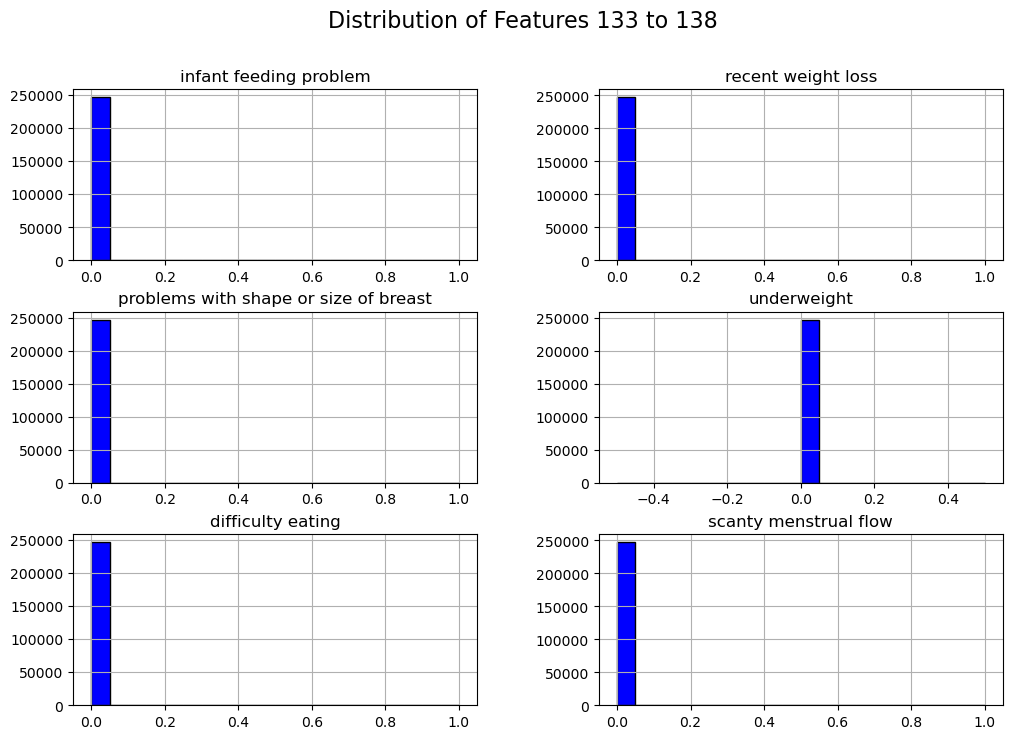

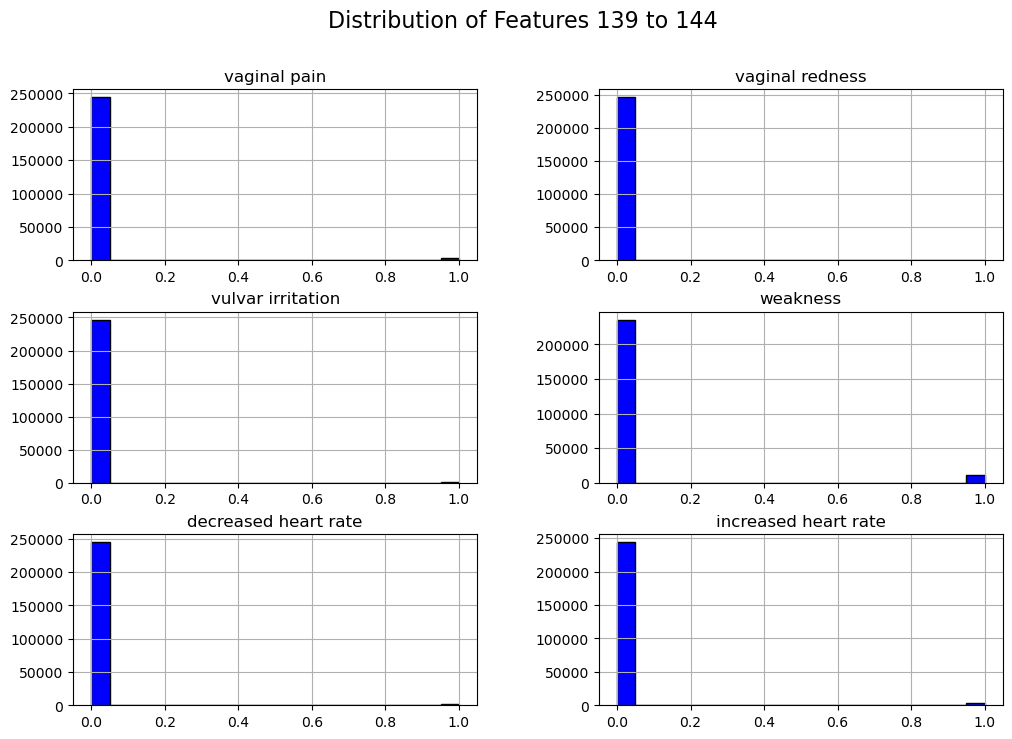

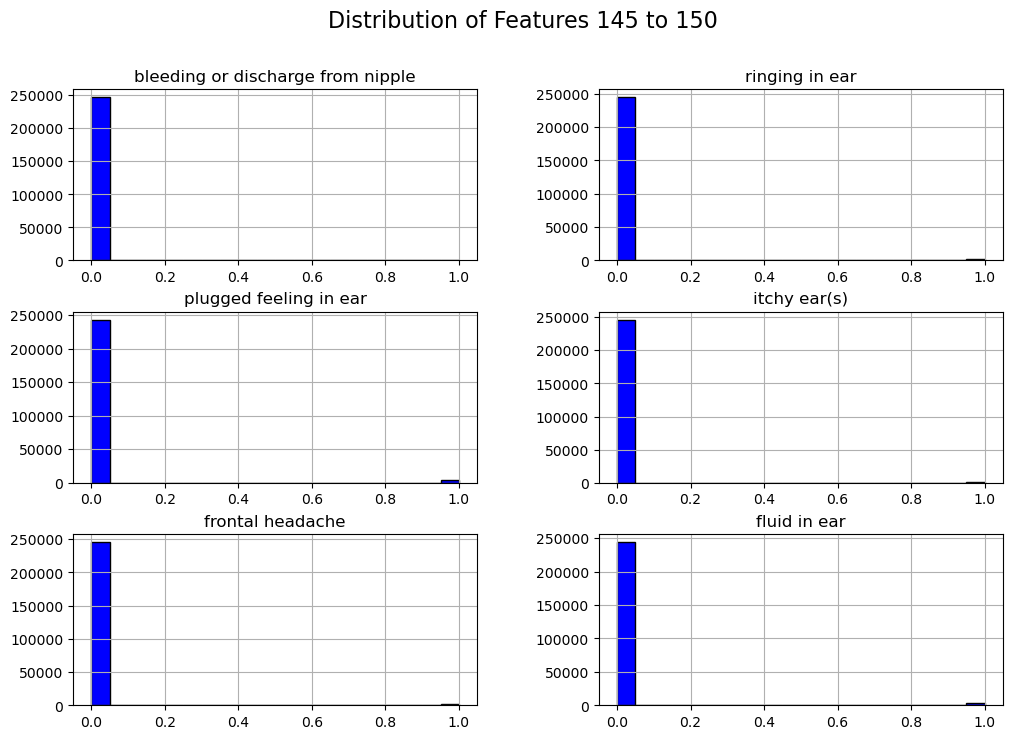

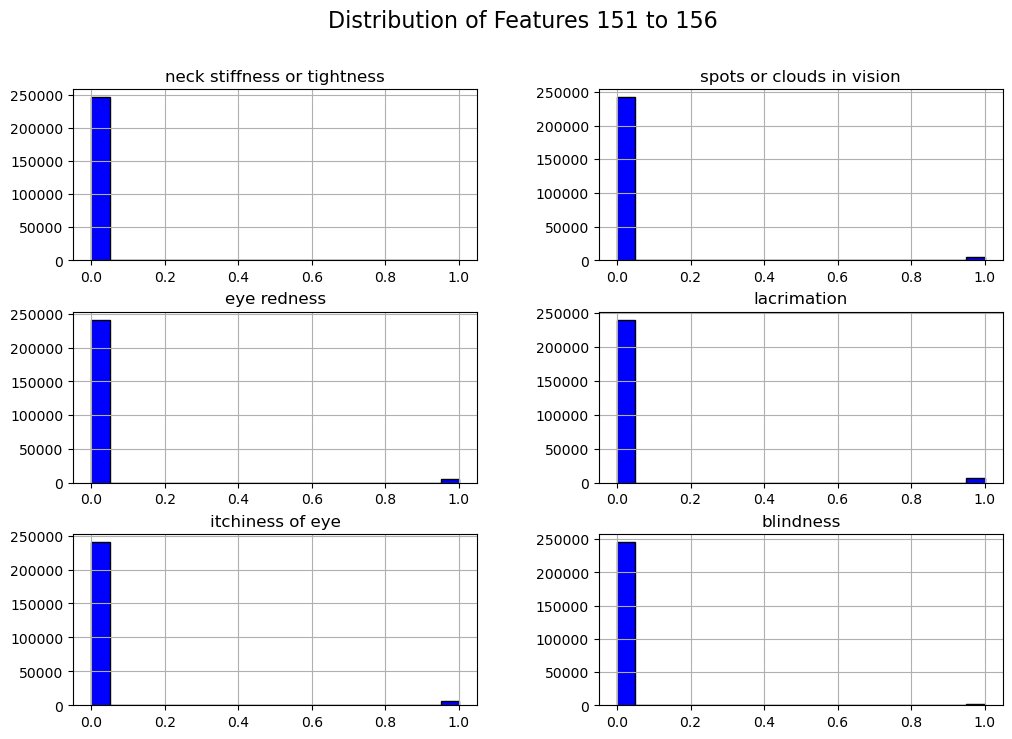

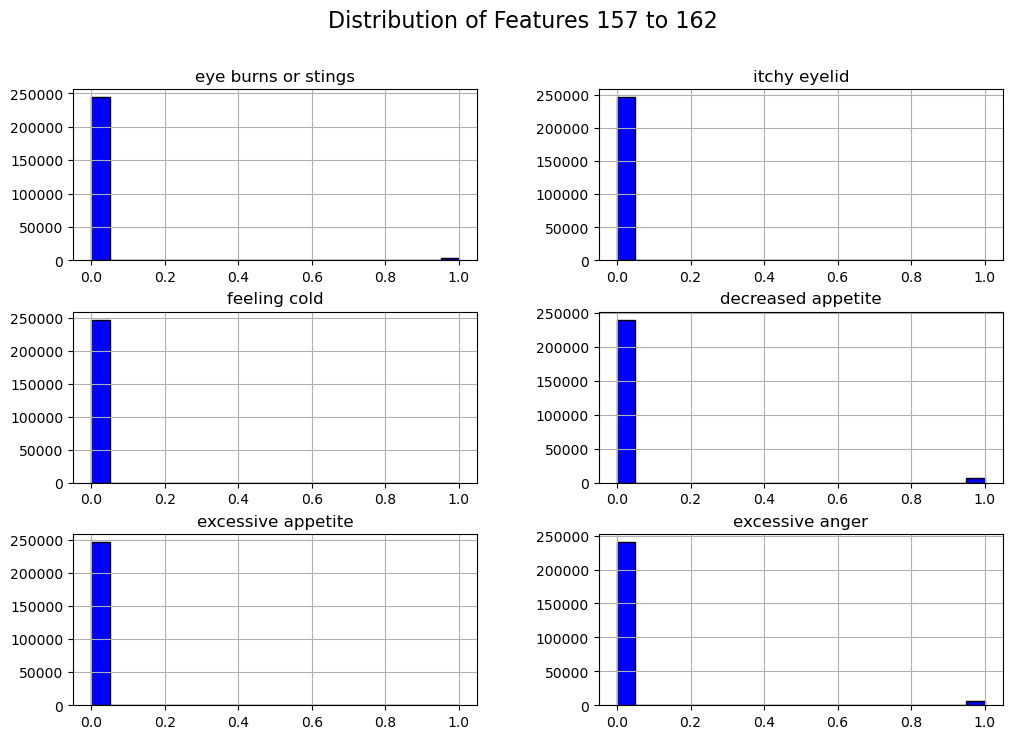

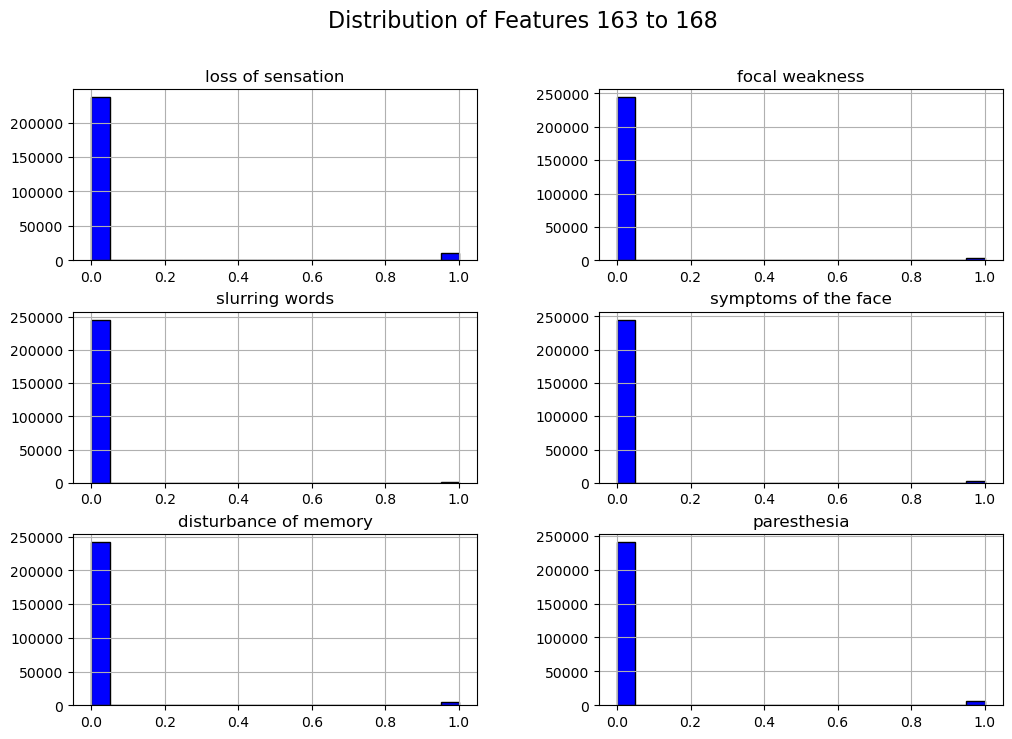

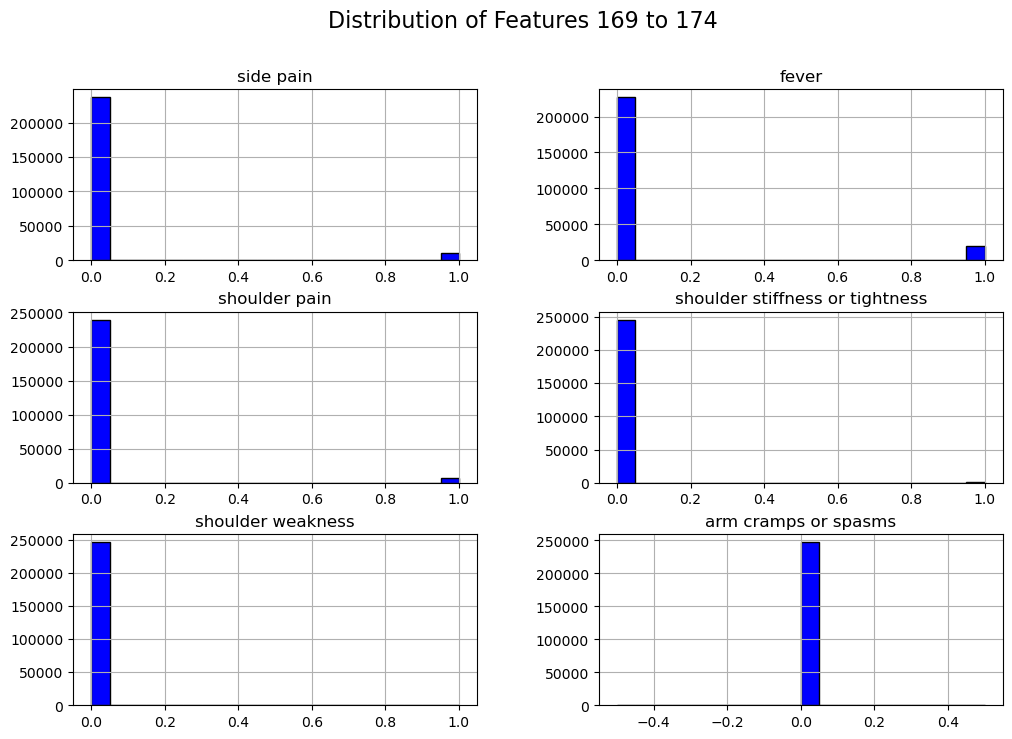

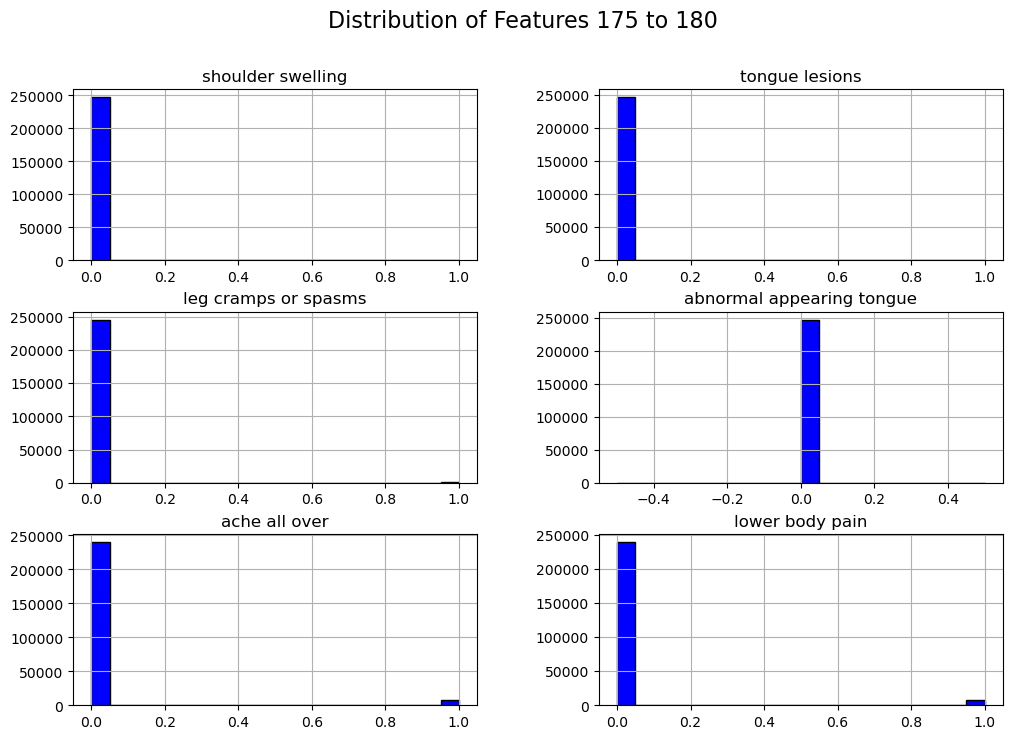

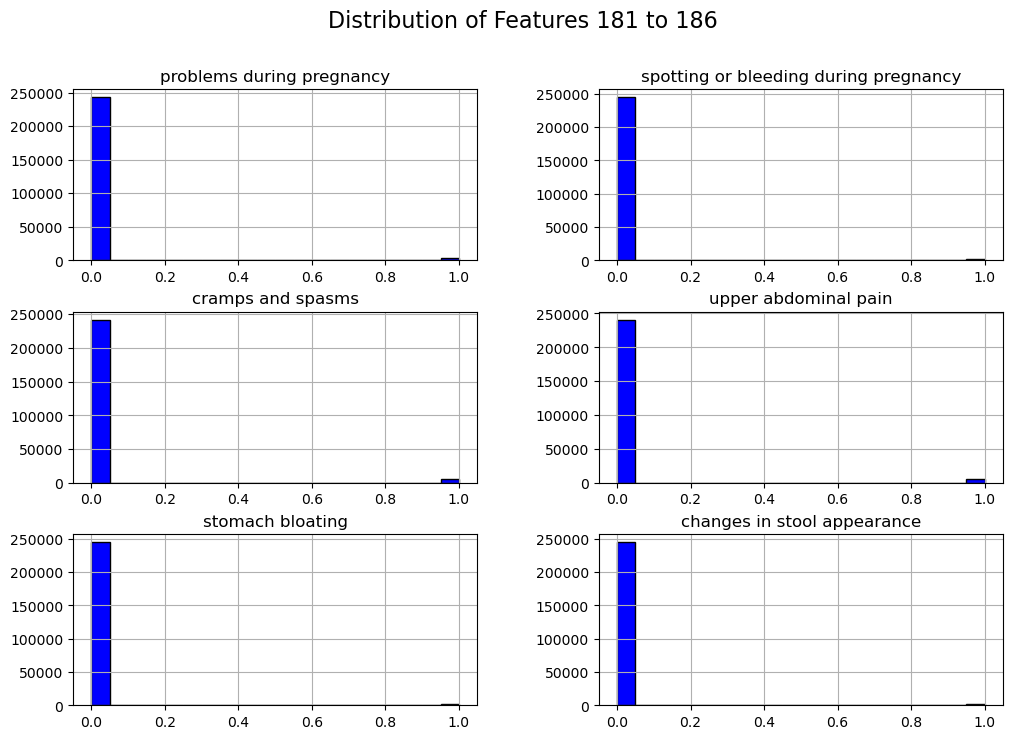

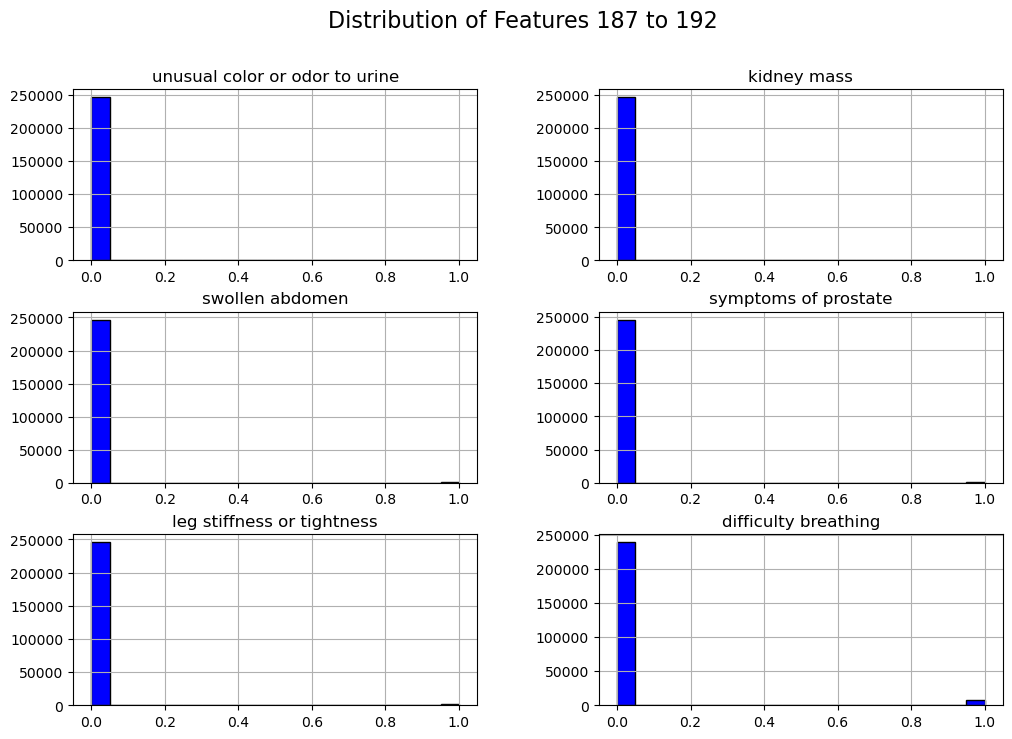

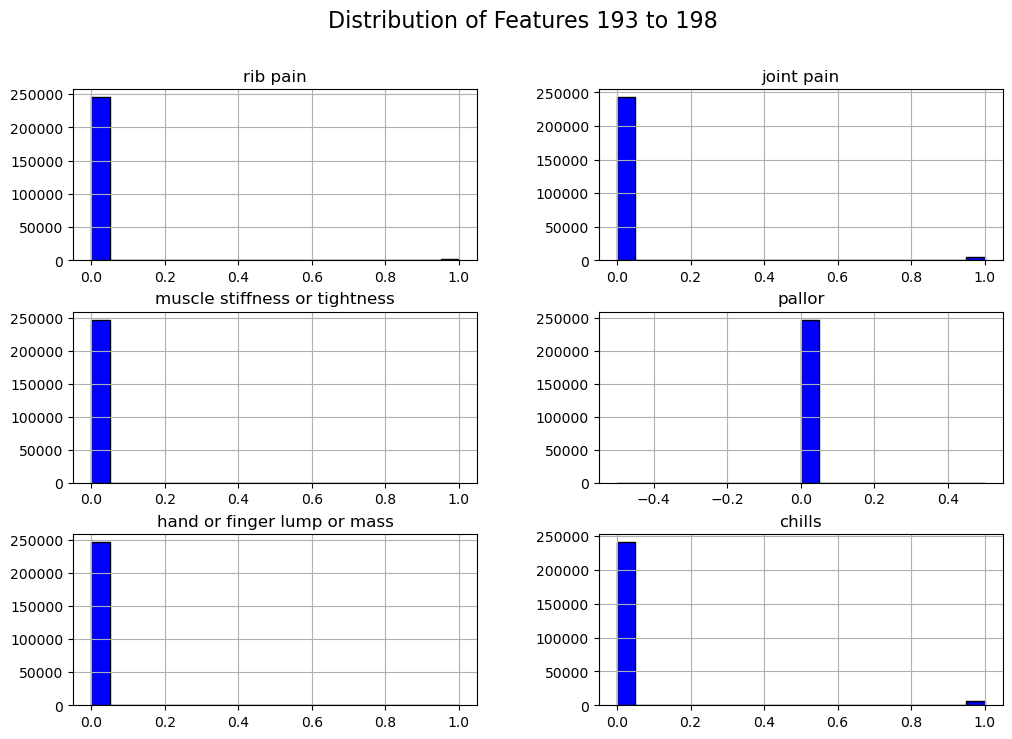

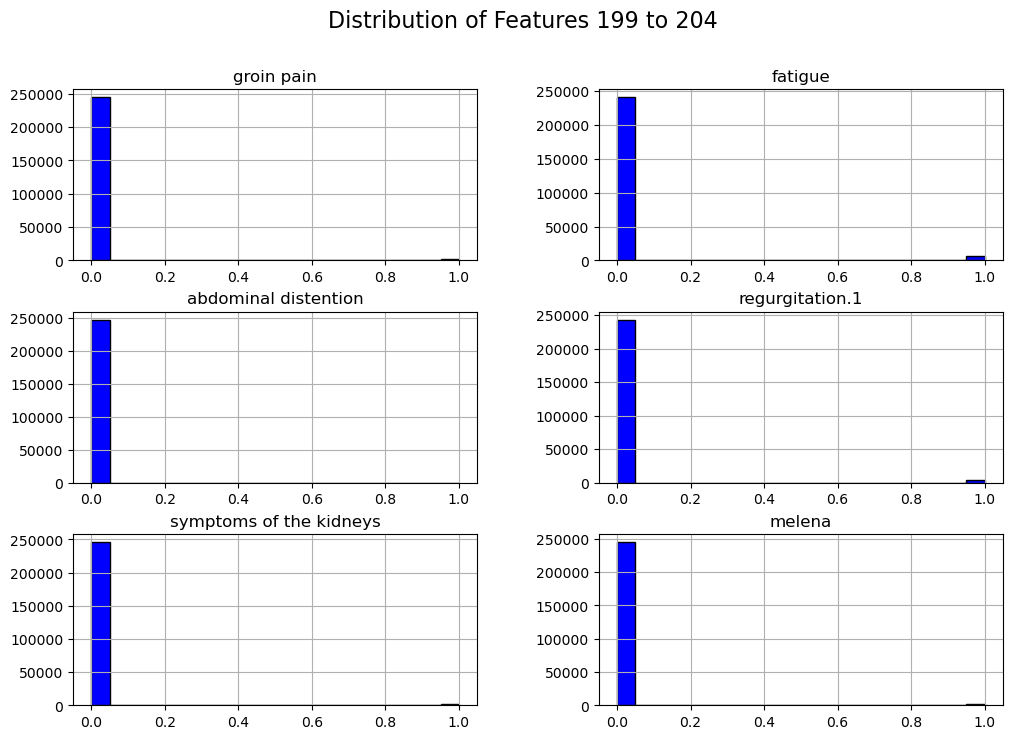

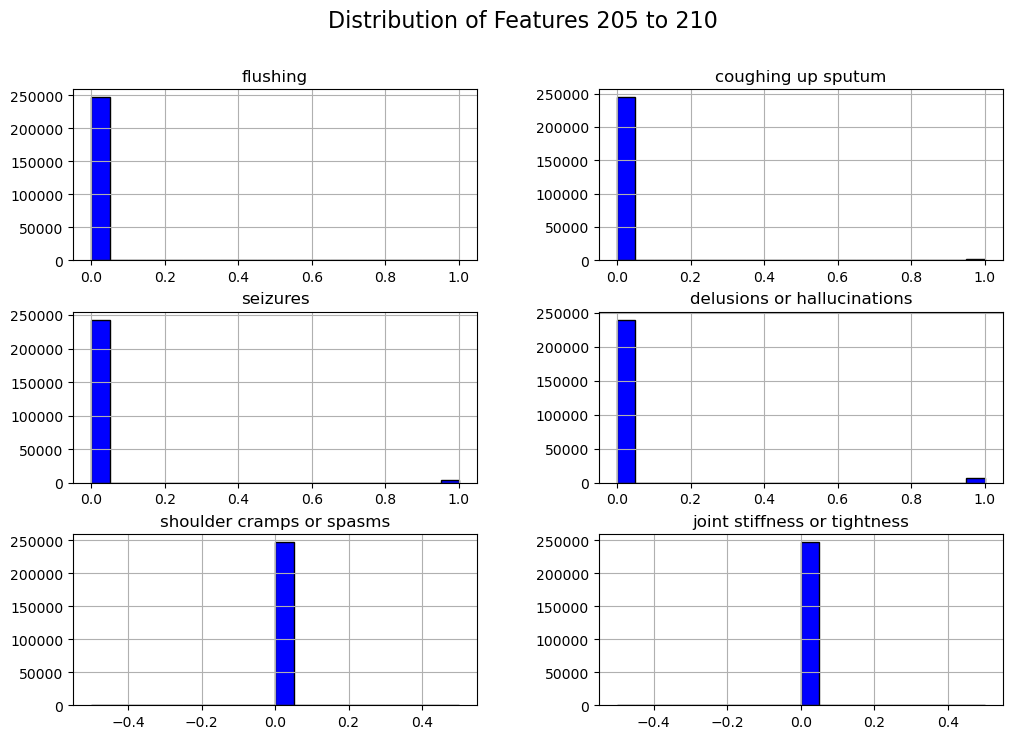

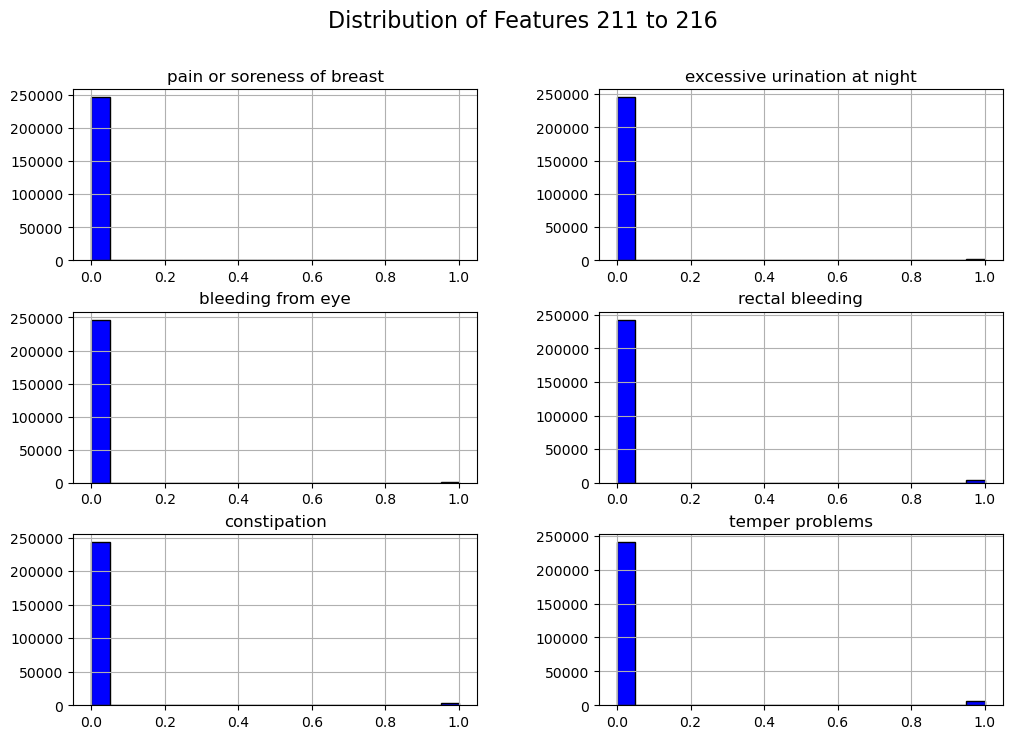

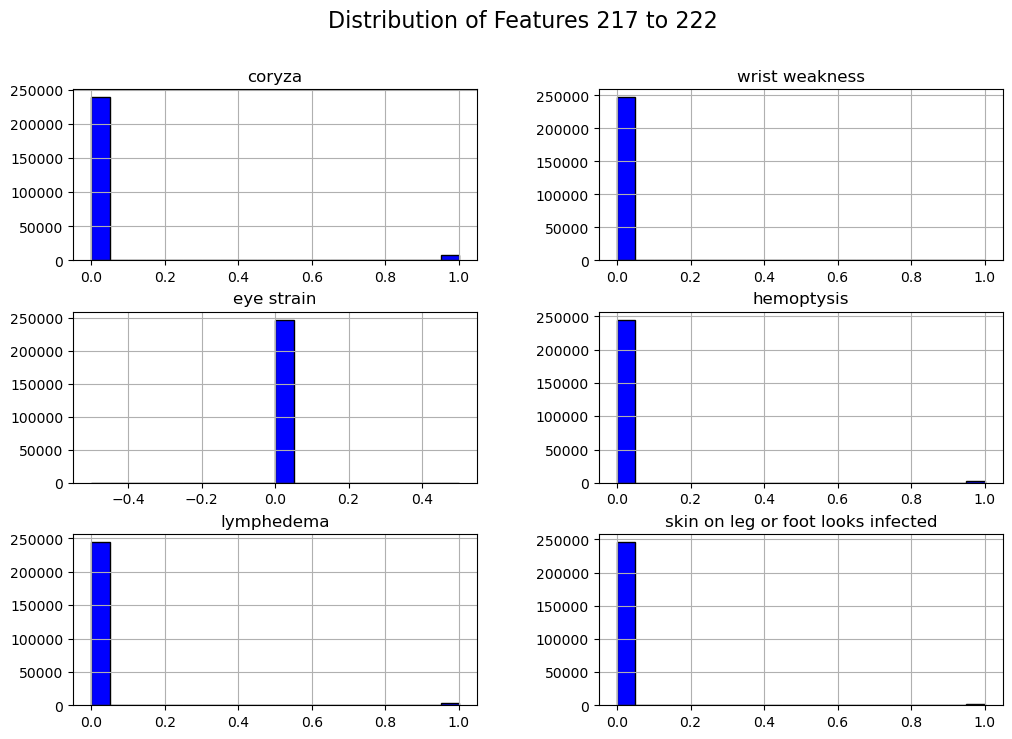

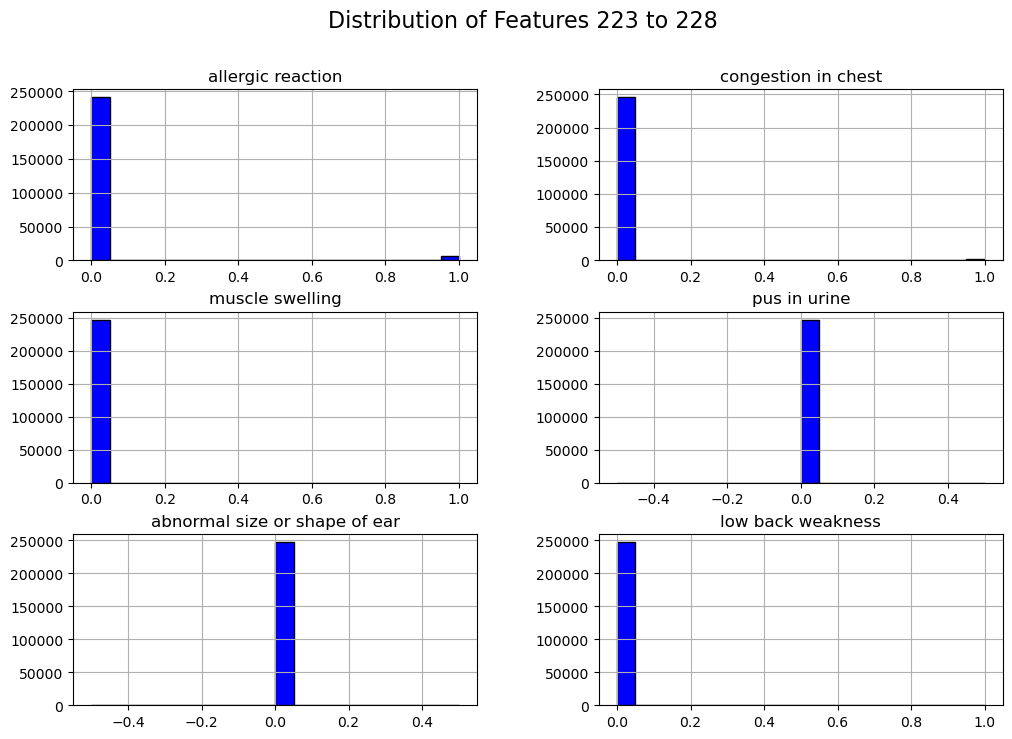

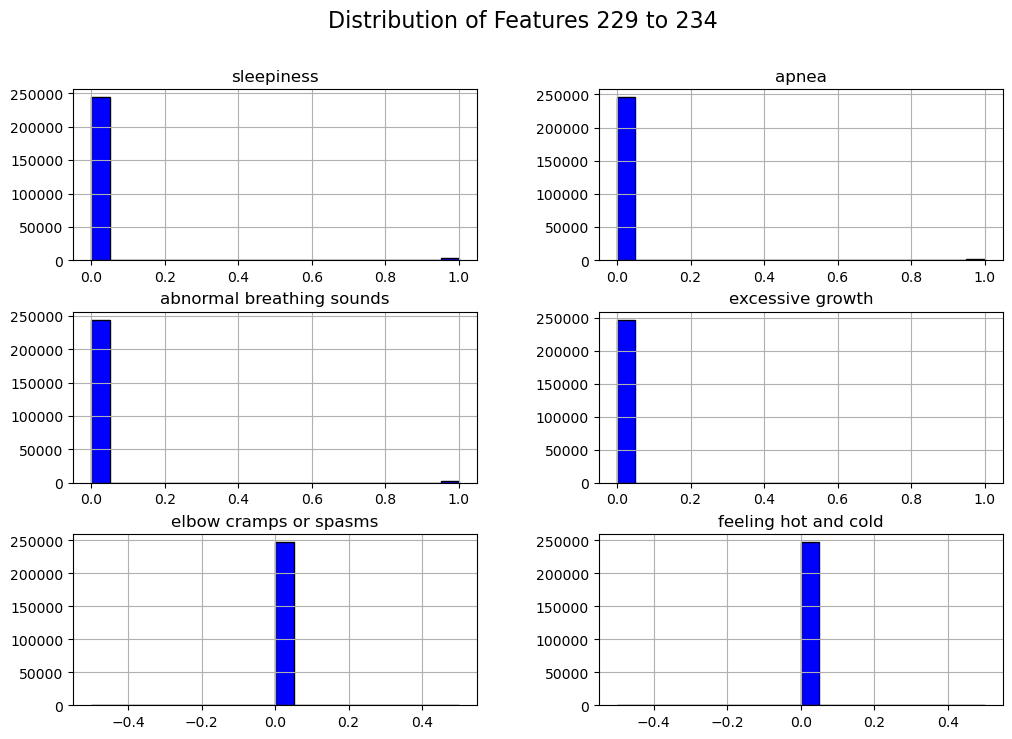

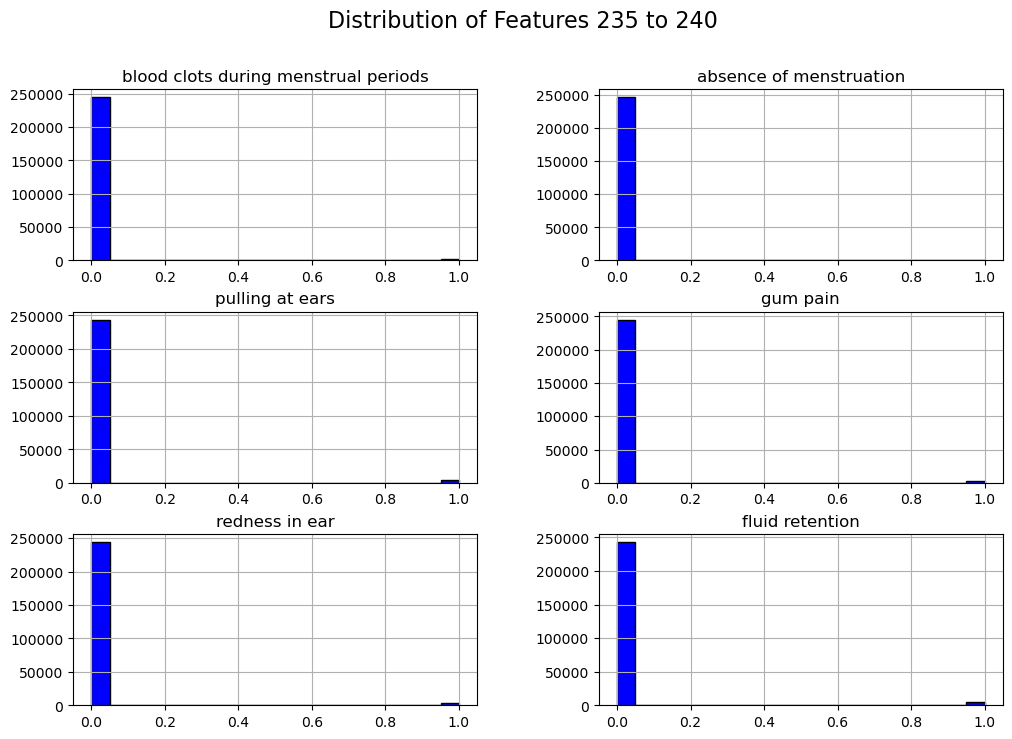

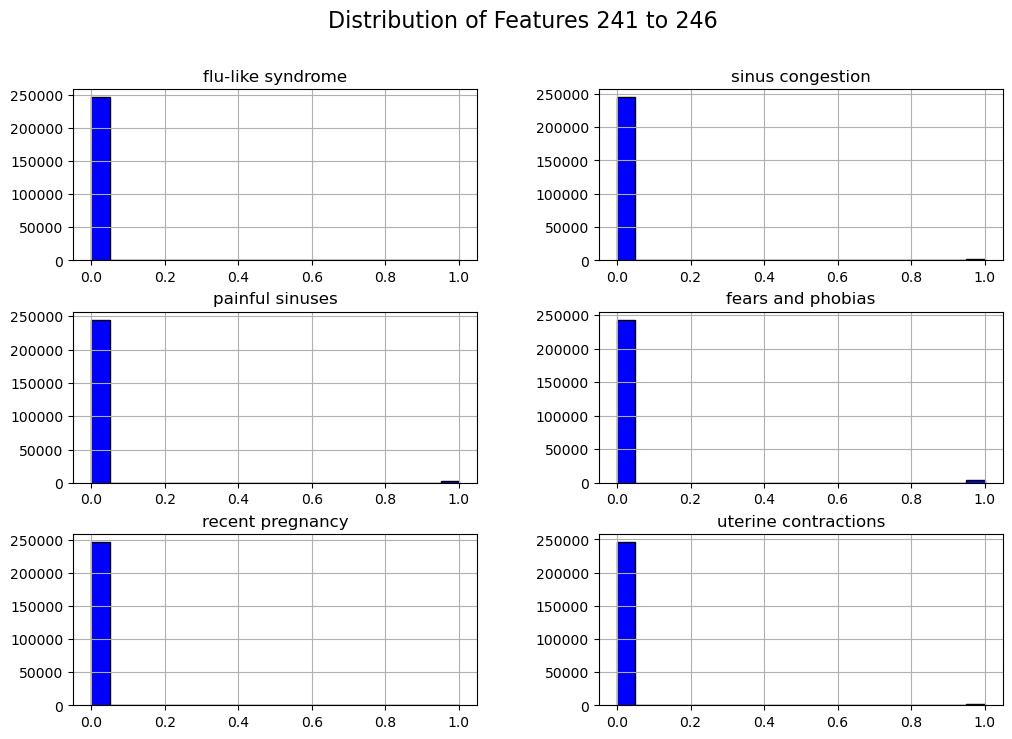

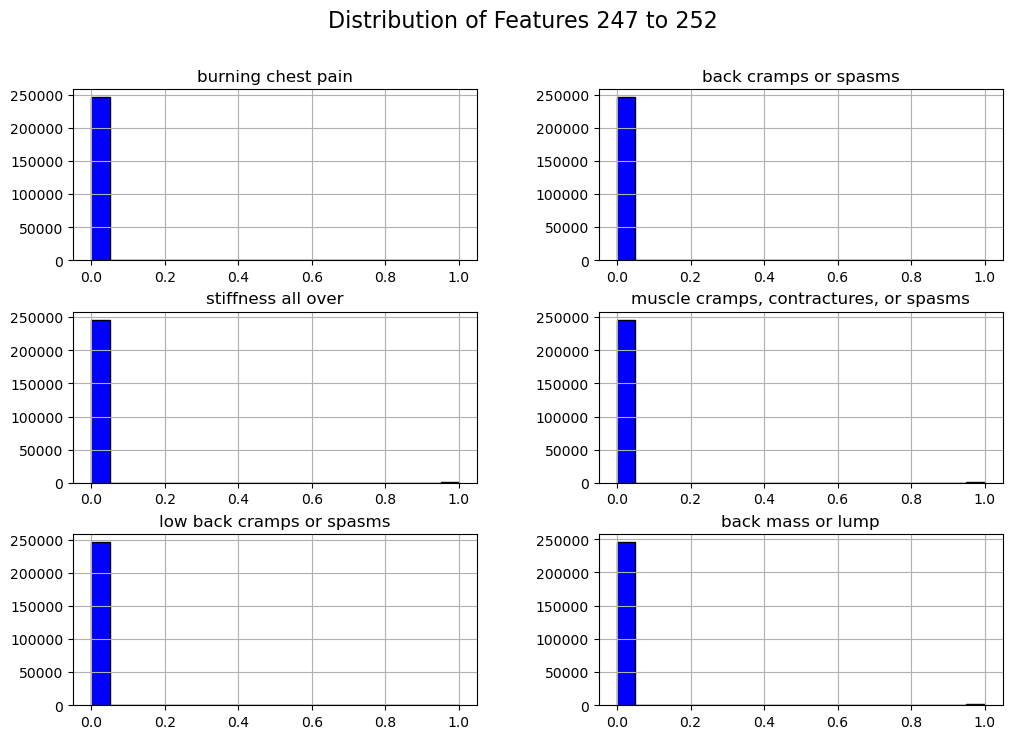

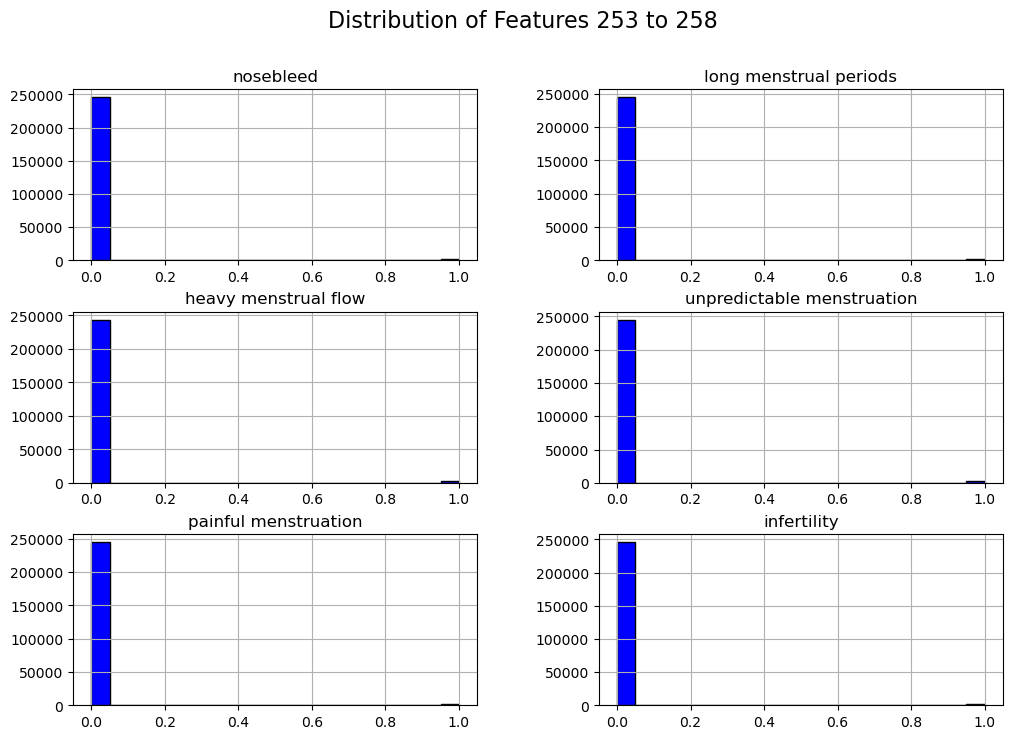

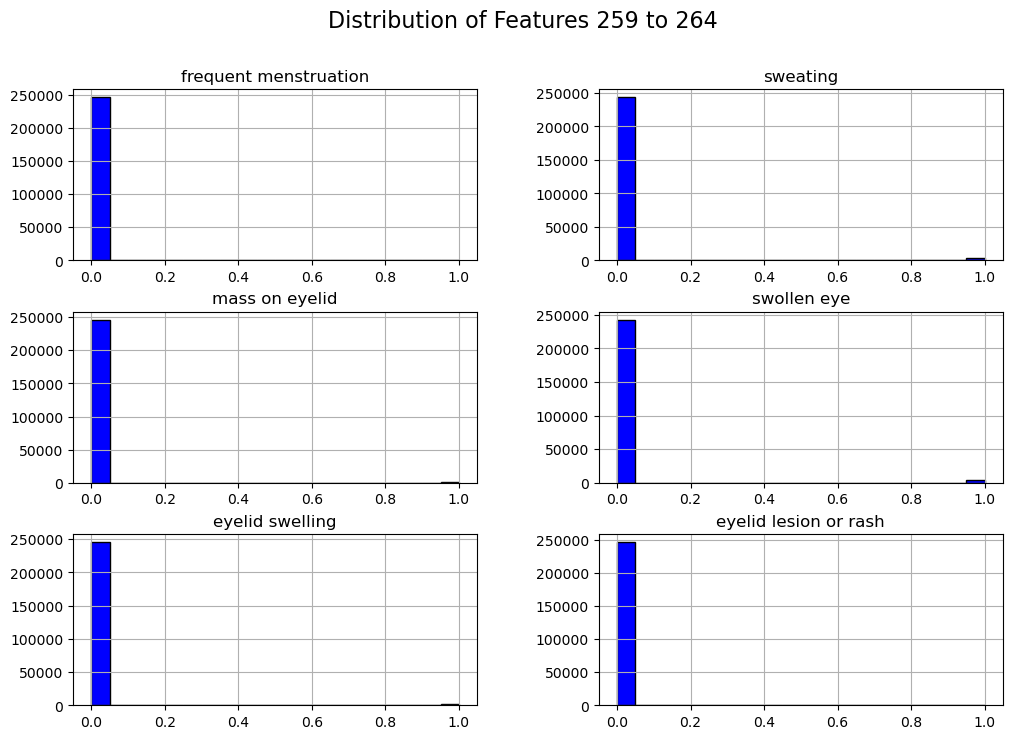

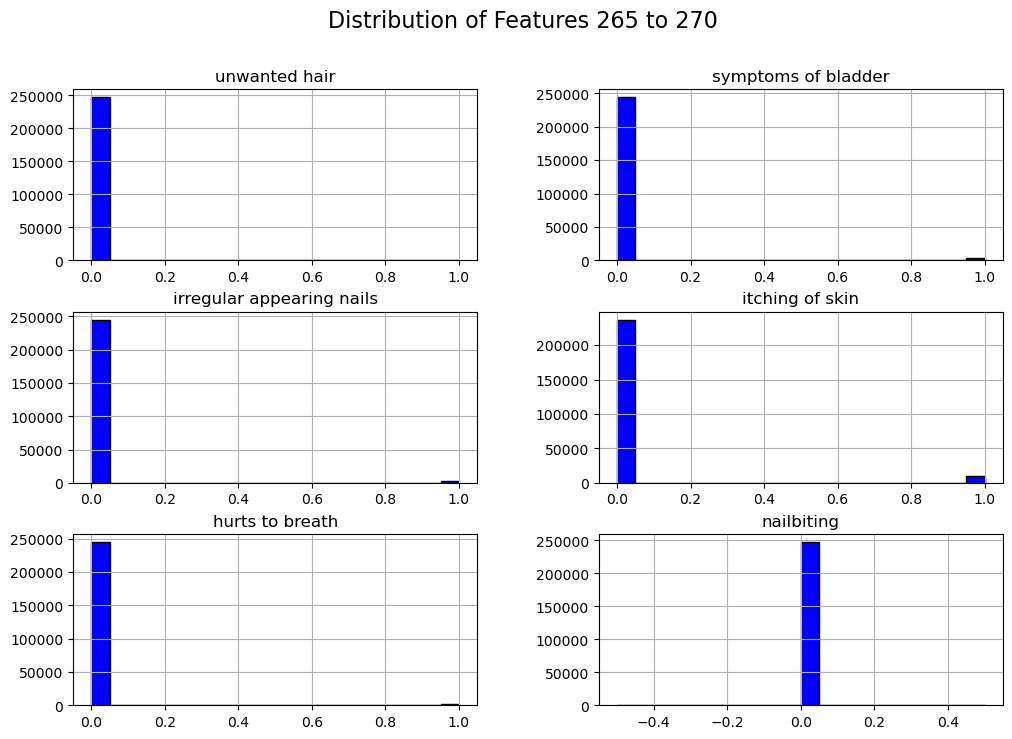

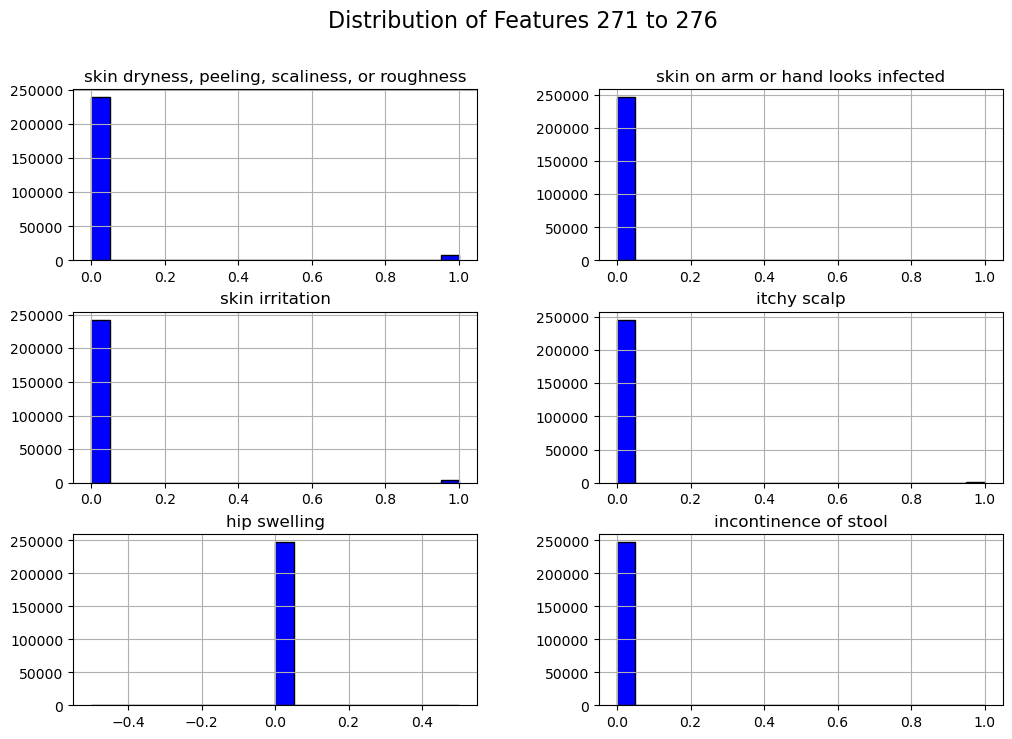

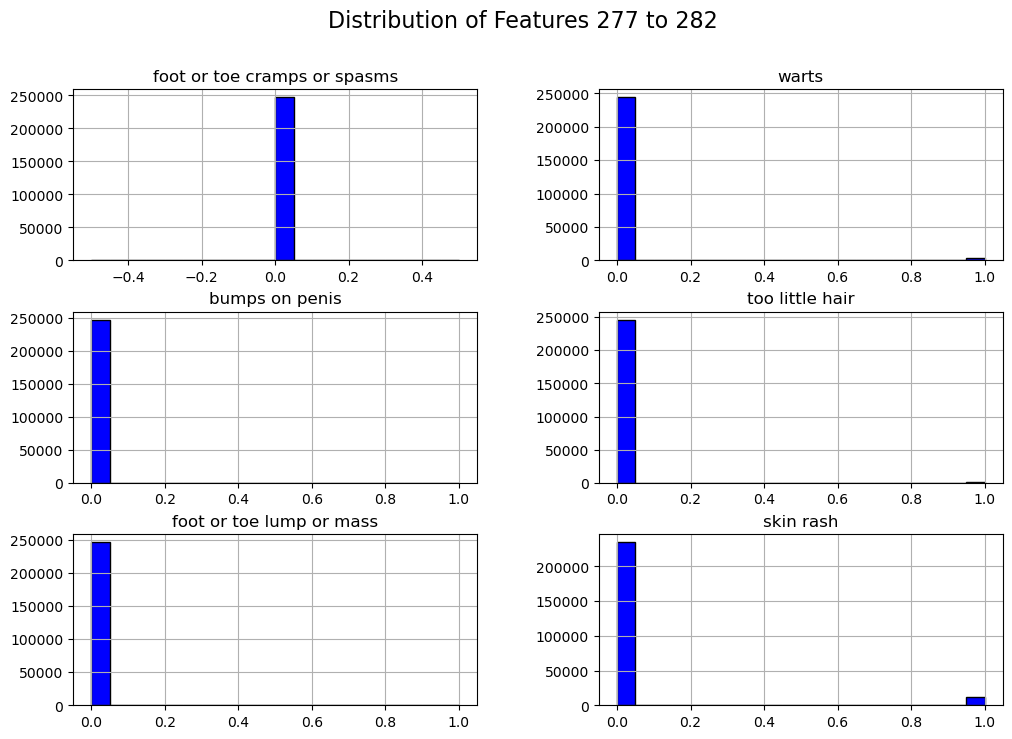

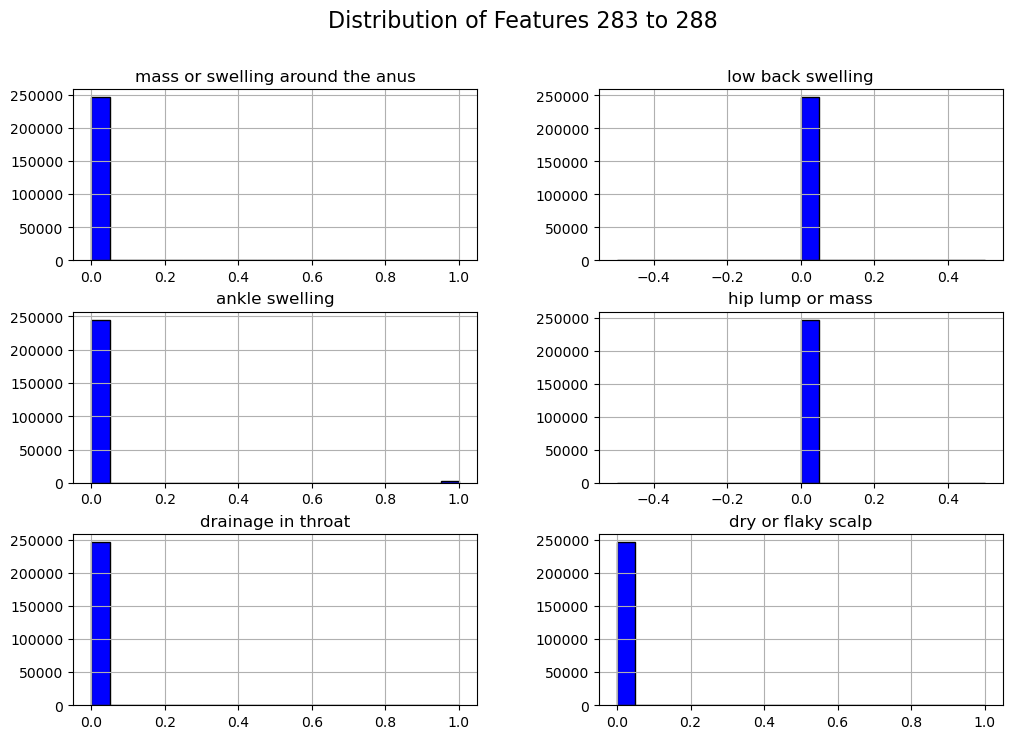

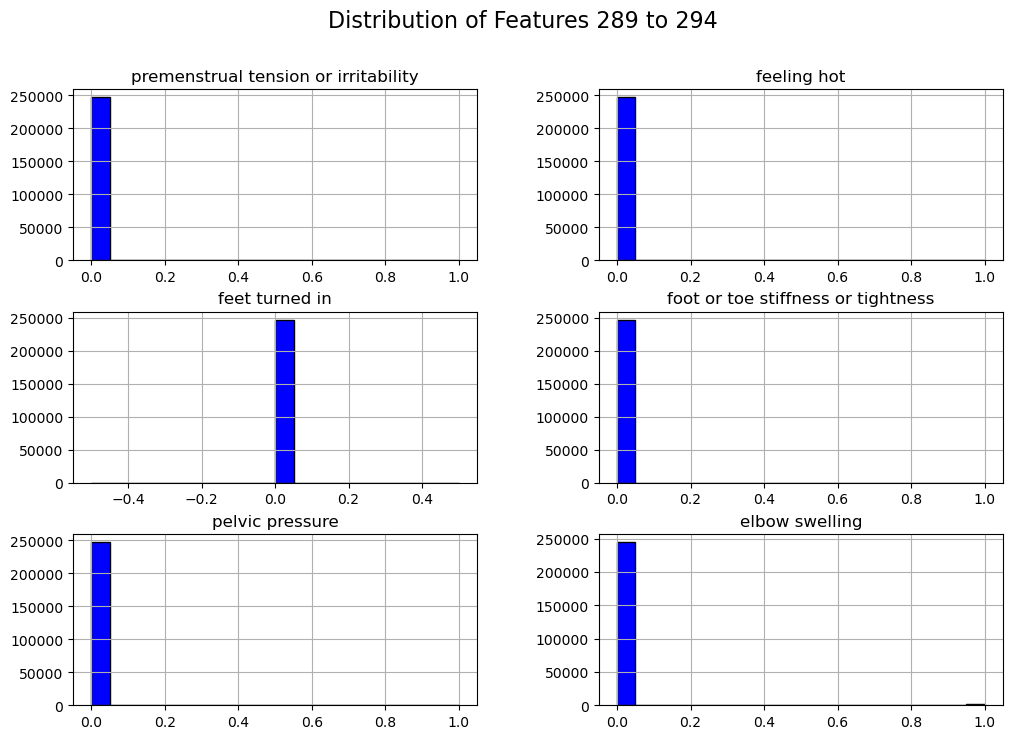

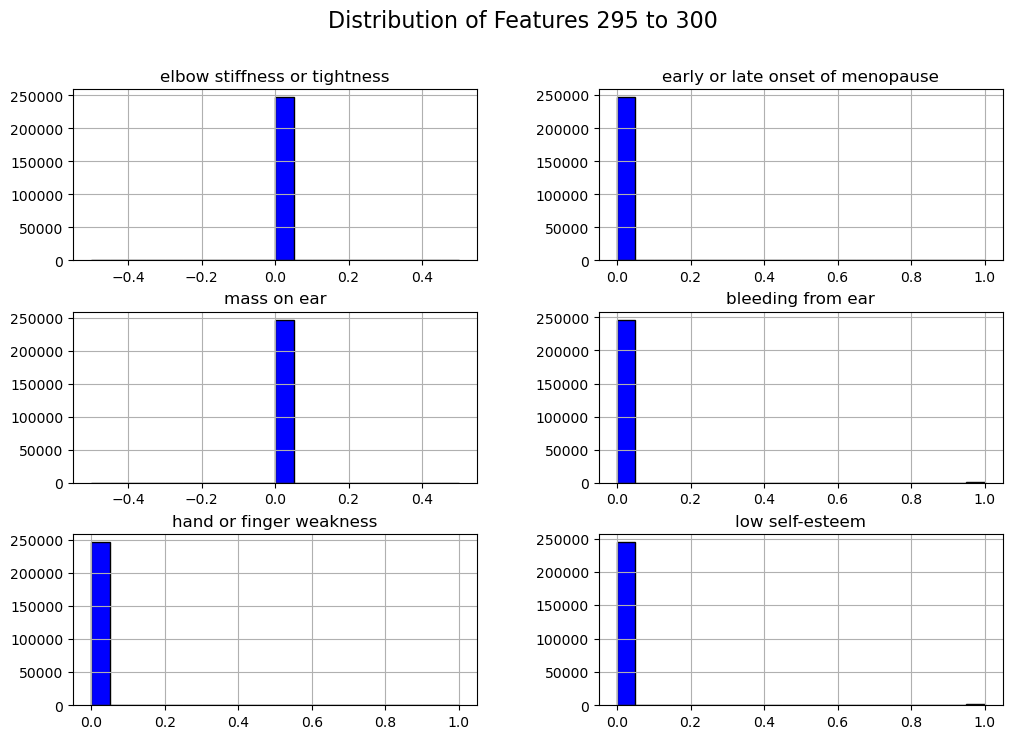

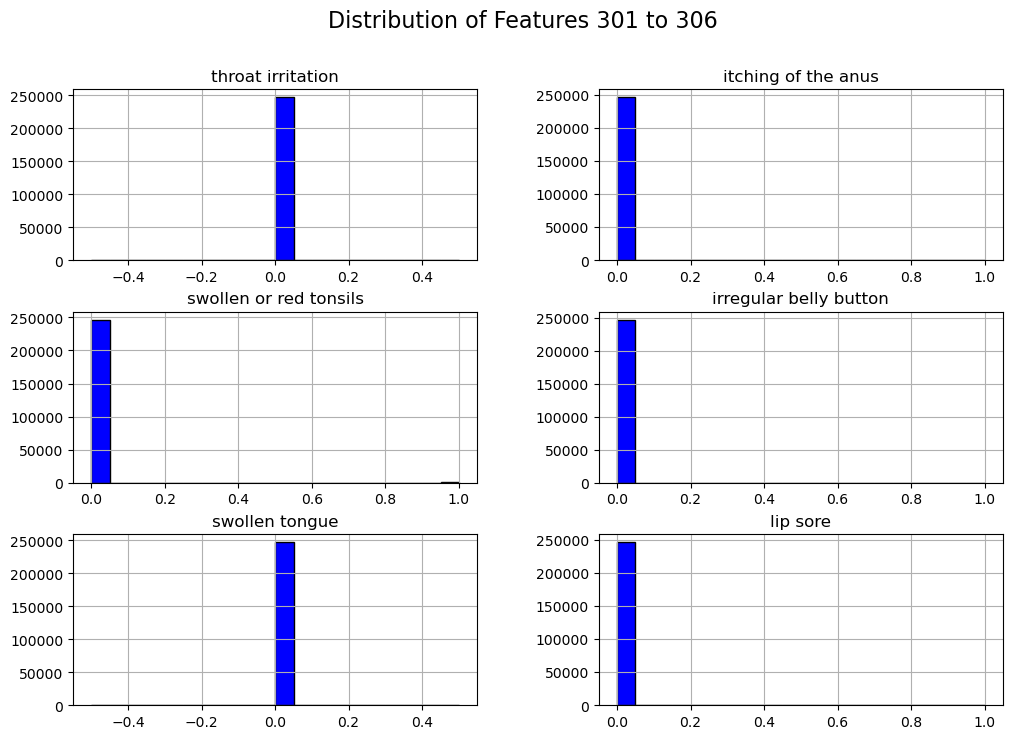

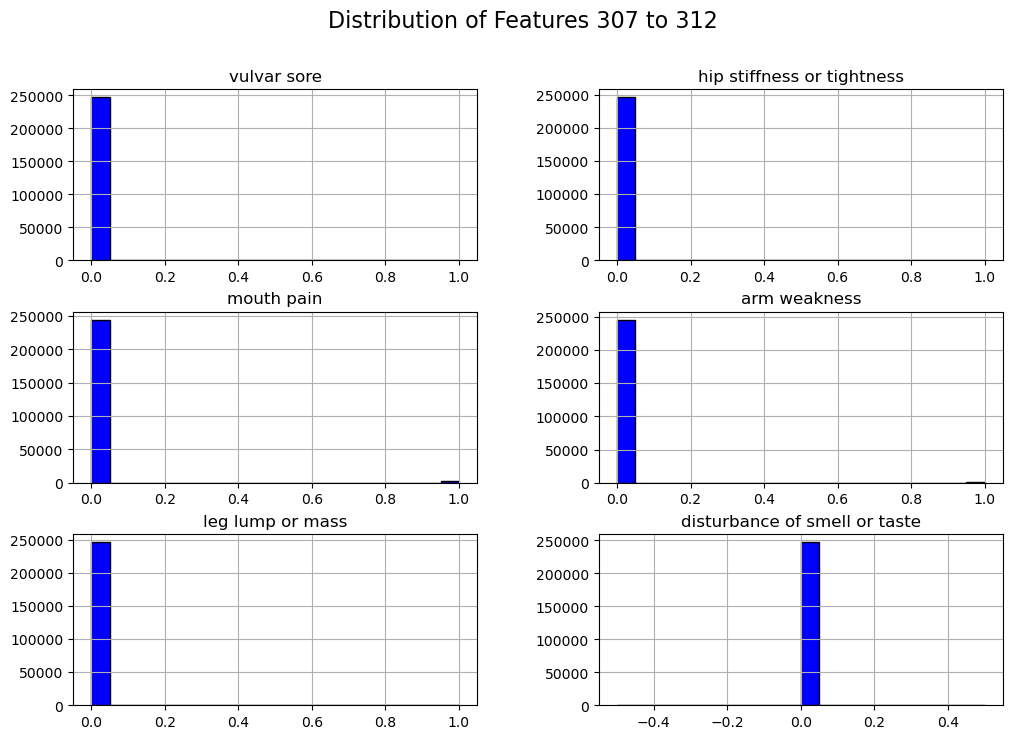

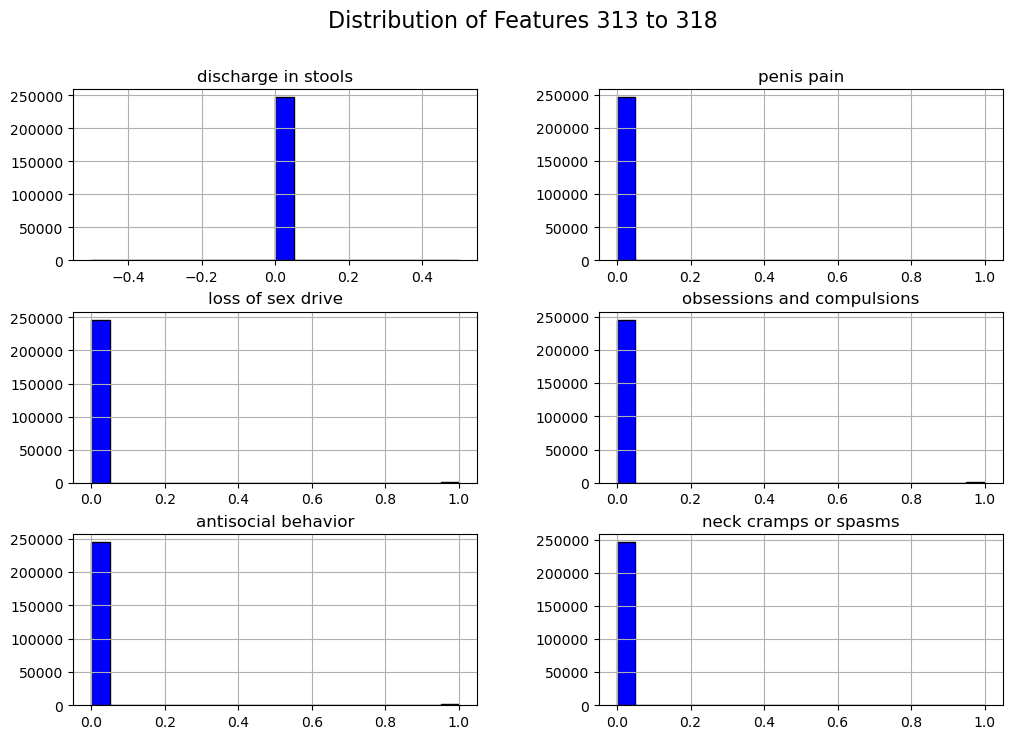

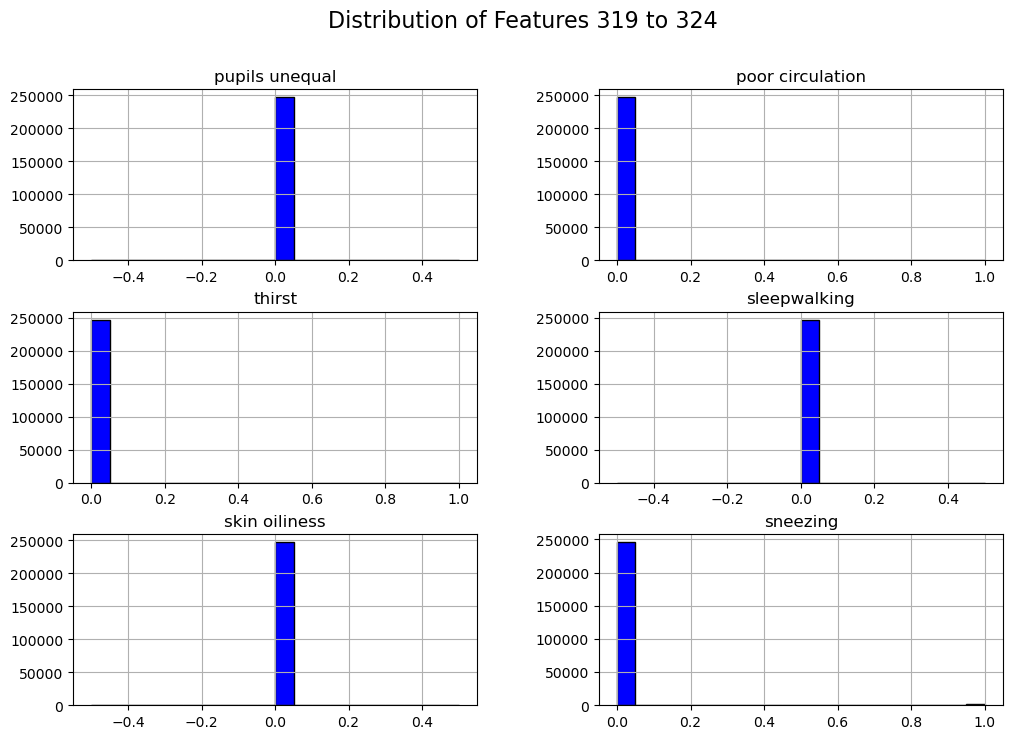

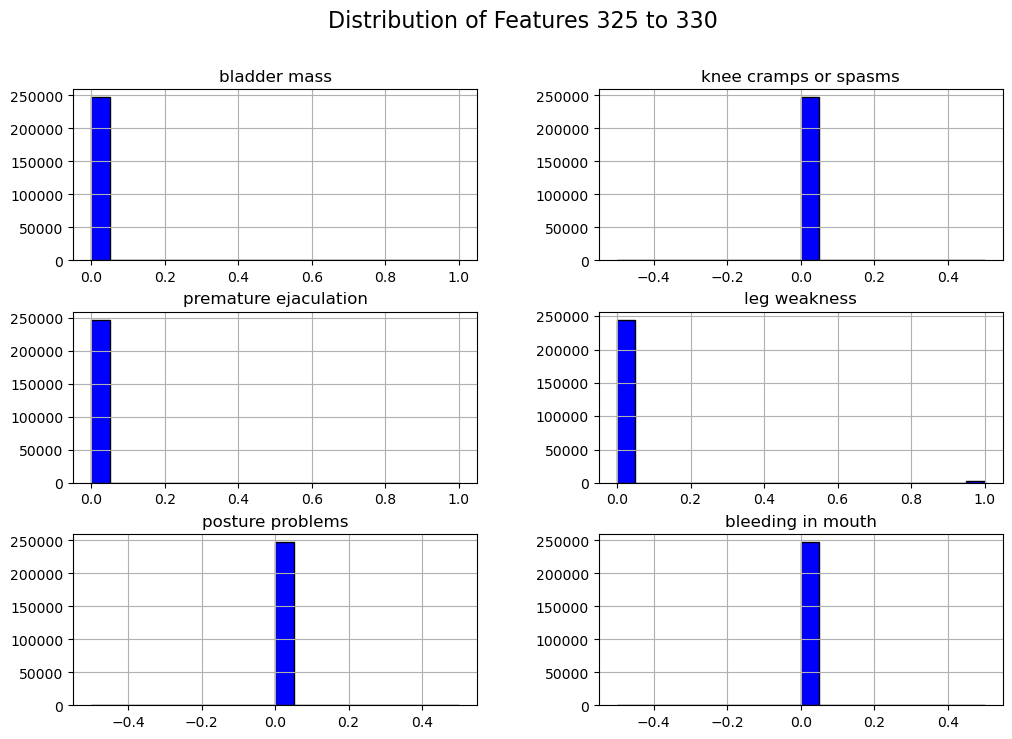

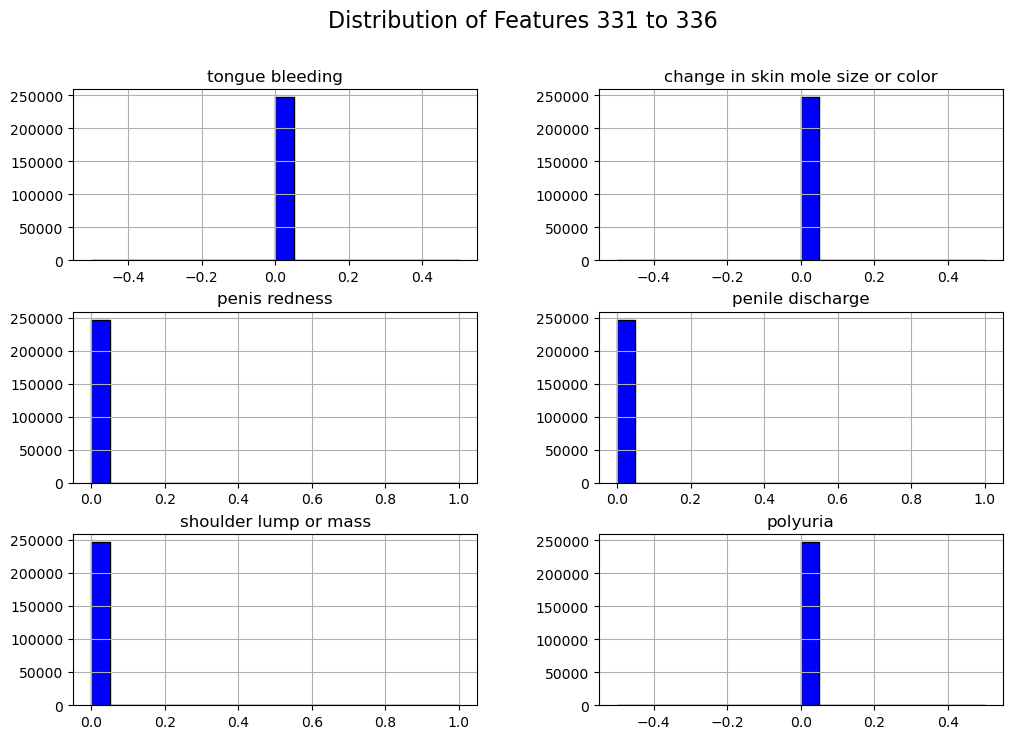

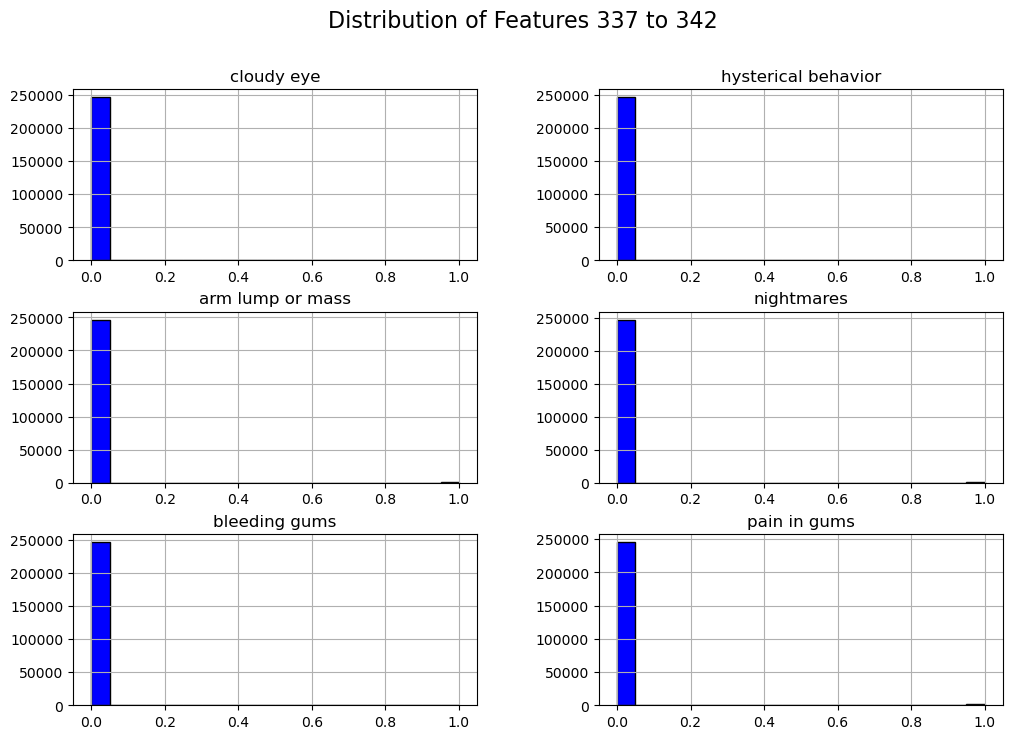

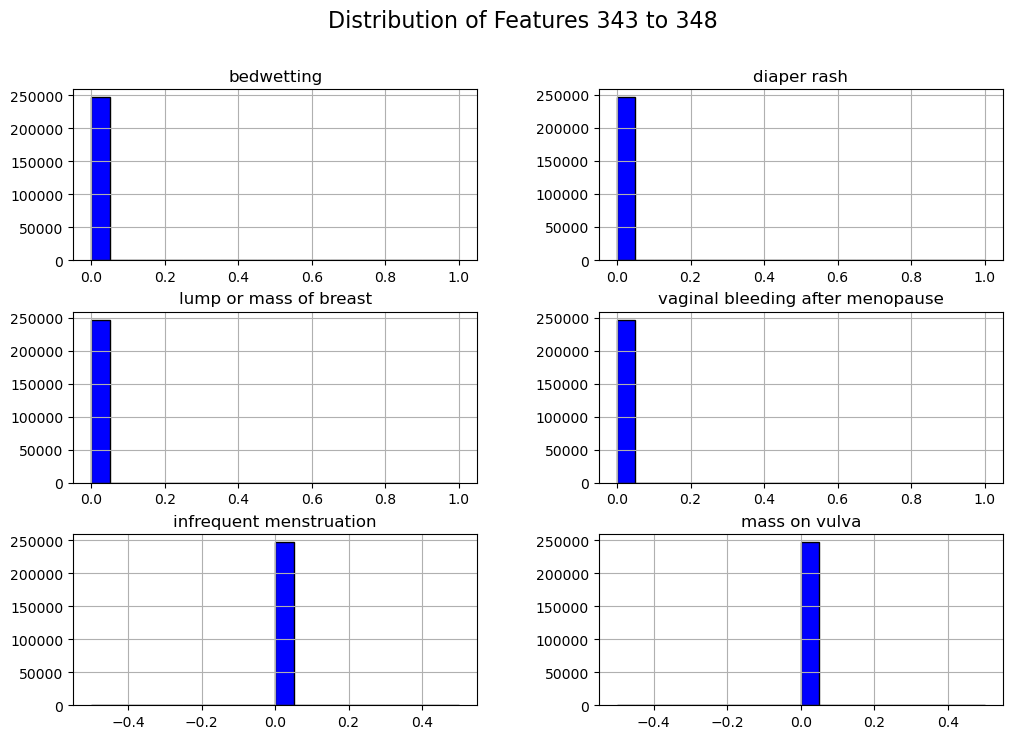

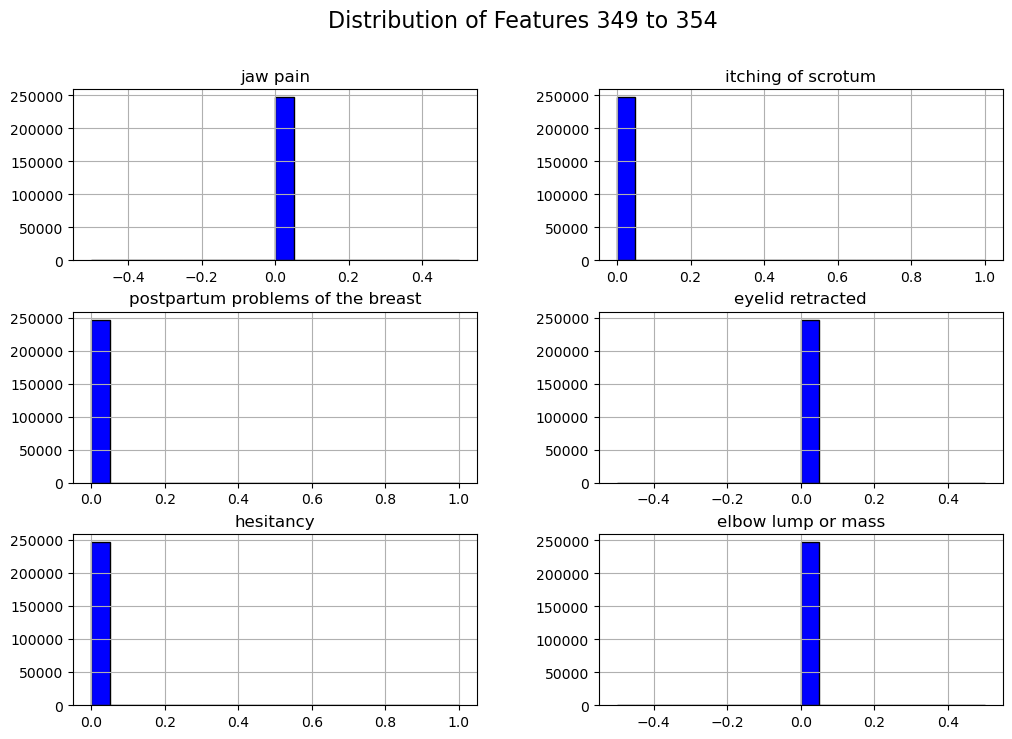

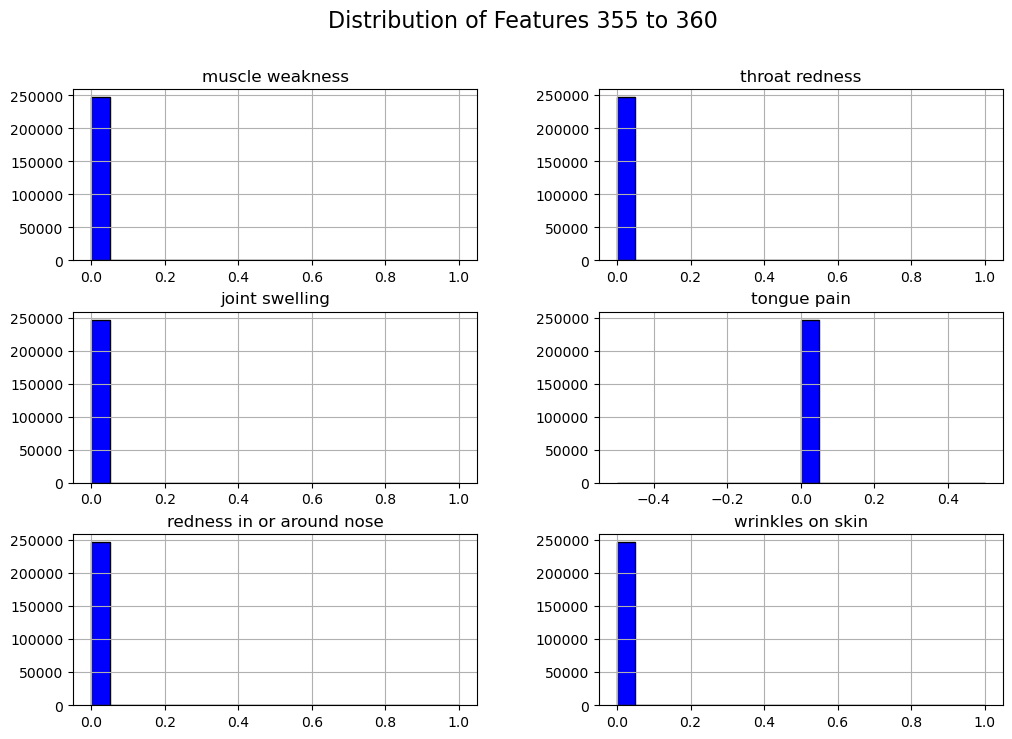

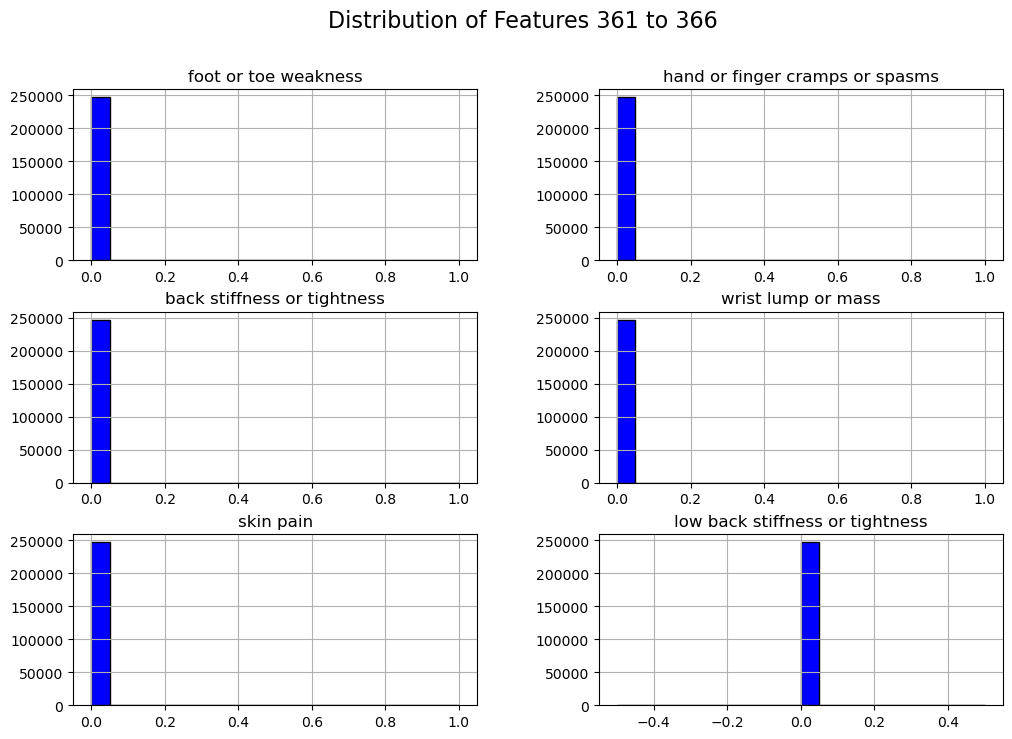

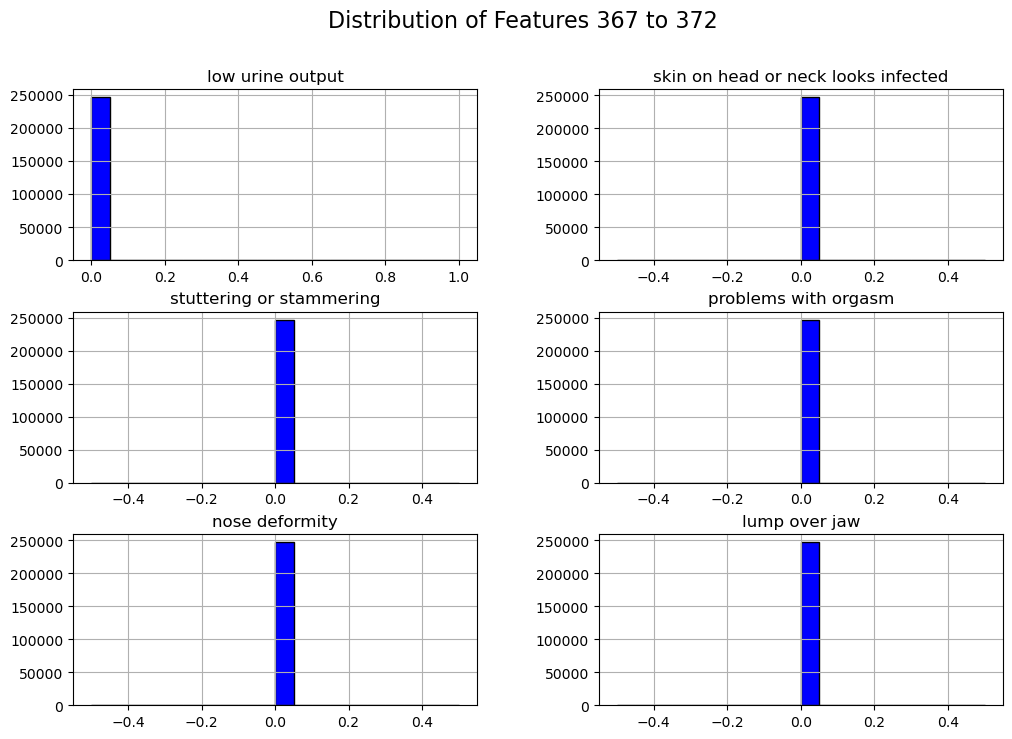

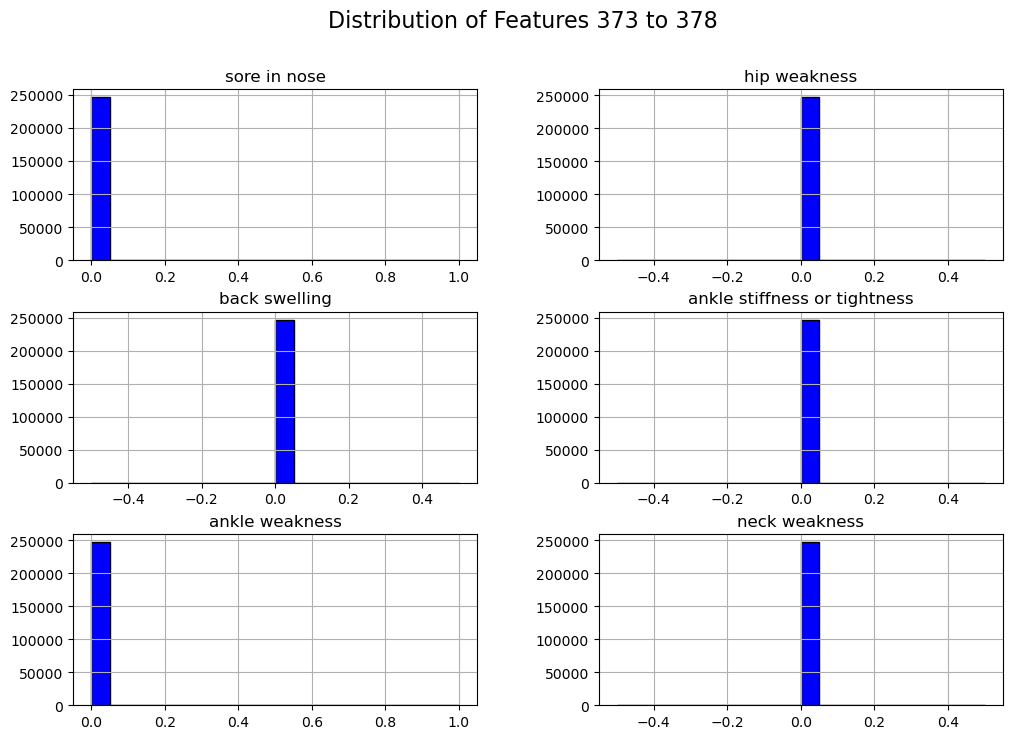

In [6]:
batch_size = 6  # Adjust based on your preference

# Loop through columns in batches
for i in range(0, len(df.columns), batch_size):
    subset = df.iloc[:, i : i + batch_size]  # Select a subset of columns

    # Plot histograms for the subset
    subset.hist(figsize=(12, 8), bins=20, color="blue", edgecolor="black")
    plt.suptitle(f"Distribution of Features {i+1} to {i+batch_size}", fontsize=16)
    plt.show()

### Correlation Heatmap

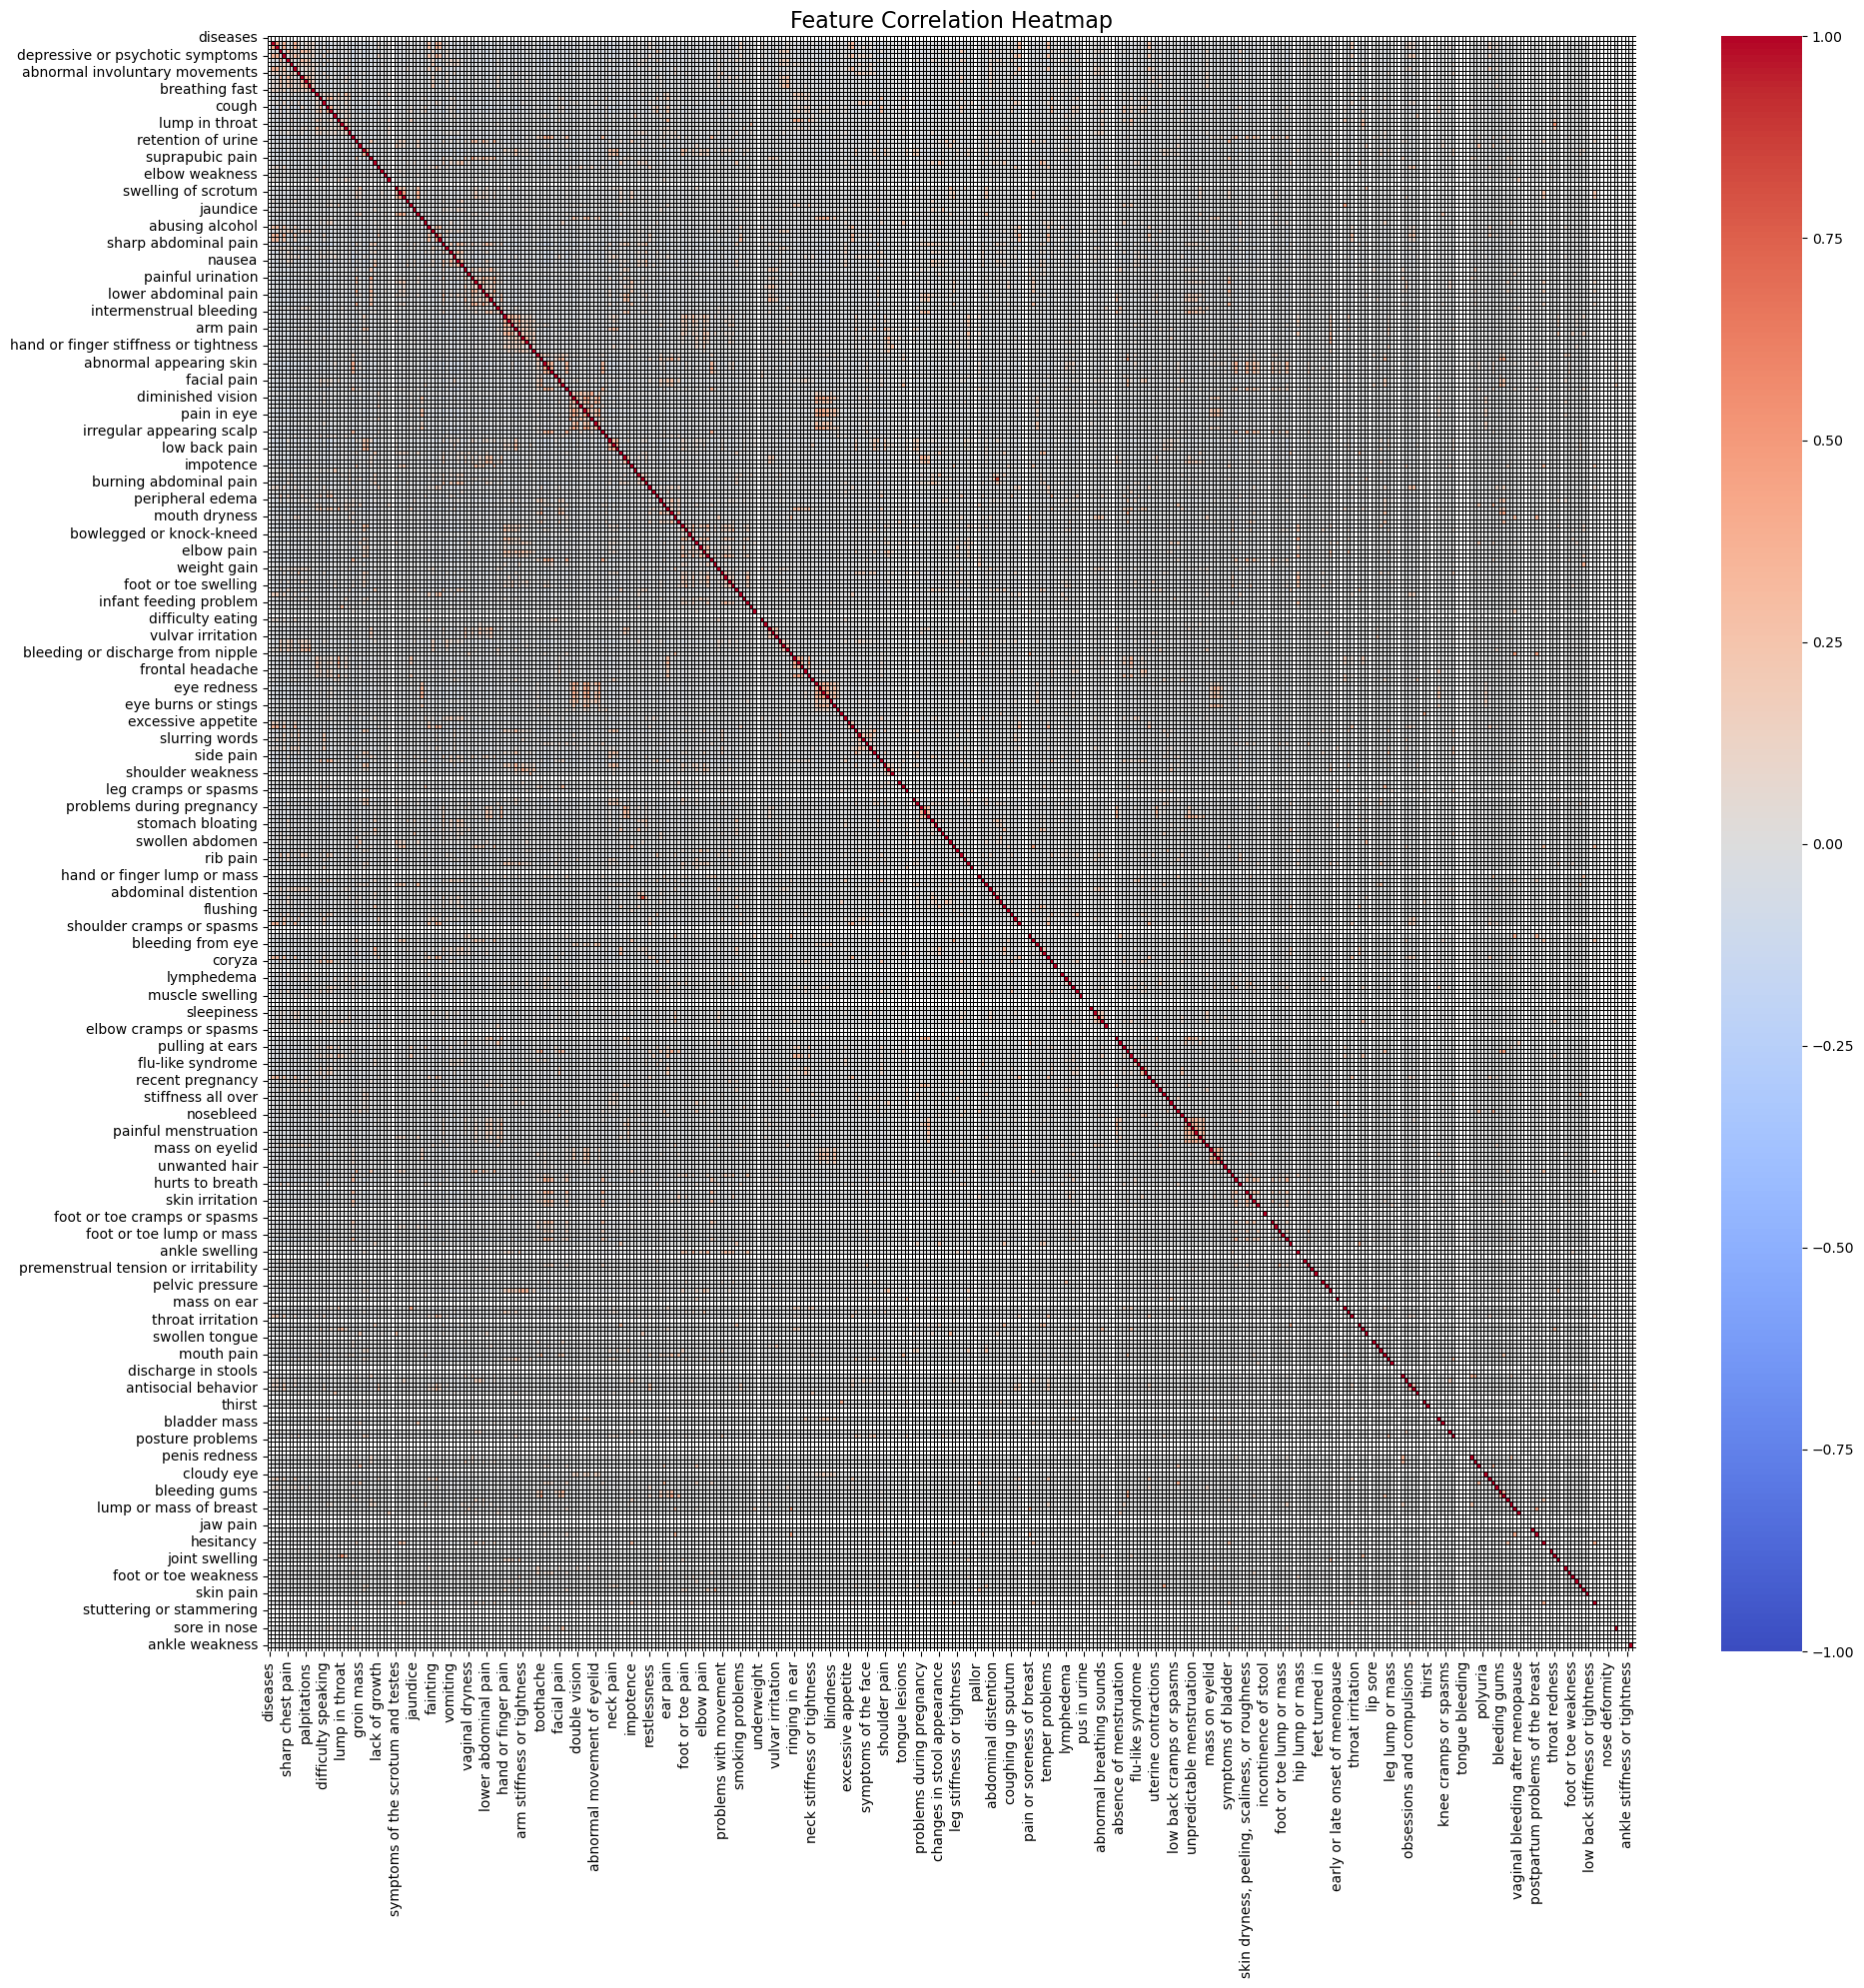

In [13]:
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# create the hearmap using seaborn and matplotlib
plt.figure(figsize=(20,20))
sns.heatmap(df_numeric.corr(), annot=False, cmap="coolwarm",vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, linecolor='black')
plt.title("Feature Correlation Heatmap", fontsize = 16)
plt.xticks(rotation =90, fontsize=10)
plt.yticks(rotation = 0, fontsize = 10)
# improve layout to prevent labels from overlapping
plt.tight_layout()
plt.show()